In [87]:
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [88]:
def plot_bar_chart(df, x, hue, title, facet=None, stacked_by=None, rotate=False):
    plt.figure(figsize=(16,6))
    
    if stacked_by:
        # group and pivot for stacked bar chart (use mean for percentages)
        if facet:
            pivot_df = df.groupby([x, hue, facet])['value'].mean().reset_index()
            for fac in df[facet].unique():
                sub = pivot_df[pivot_df[facet] == fac]
                pivot = sub.pivot(index=x, columns=hue, values='value').fillna(0)
                ax = pivot.plot(kind='bar', stacked=True, ax=plt.gca())
                plt.legend(title=stacked_by)
                # add labels to each bar segment
                for cidx, col in enumerate(pivot_df.columns):
                    for ridx, val in enumerate(pivot_df[col]):
                        if val > 0:
                            bottom = pivot_df.iloc[ridx, :cidx].sum()
                            ax.text(ridx, bottom + val/2, f"{val:.1f}", ha='center', va='center', fontsize=9, color="white" if val > 5 else "black")
        else: 
            pivot_df = df.groupby([x, hue])['value'].mean().unstack(fill_value=0)
            ax = pivot_df.plot(kind='bar', stacked=True, ax=plt.gca())
            plt.legend(title=stacked_by)
            # add labels to each bar segment
            for cidx, col in enumerate(pivot_df.columns):
                for ridx, val in enumerate(pivot_df[col]):
                    if val > 0:
                        bottom = pivot_df.iloc[ridx, :cidx].sum()
                        ax.text(ridx, bottom + val/2, f"{val:.1f}", ha='center', va='center', fontsize=9, color="white" if val > 5 else "black")
    else:
        # Regular bar chart
        if facet:
            agg_df = df.groupby([x, hue, facet])['value'].mean().reset_index()
            ax = sns.catplot(data=agg_df, x=x, y='value', hue=hue, col=facet, kind='bar', height=5, aspect=1.2)
            ax.set_titles(col_template="{col_name}")

            # add labels on bars
            for ax_i in ax.axes.flatten():
                ax_i.set_ylabel('Average Percentage (%)')
                for container in ax_i.containers:
                    ax_i.bar_label(container, fmt='%.1f', padding=2)
                    
            plt.subplots_adjust(top=0.85)
            plt.suptitle(title)

        else:
            agg_df = df.groupby([x, hue])['value'].mean().reset_index()
            ax = sns.barplot(data=agg_df, x=x, y='value', hue=hue)

            if rotate:
                # ax.set_xticklabels(ax.get_xticklabels(), rotation=rotate, ha='right')
                for label in ax.get_xticklabels():
                    label.set_rotation(rotate)
                    label.set_ha('right')


            # add labels on bars
            for container in ax.containers:
                ax.bar_label(container, fmt='%.1f', padding=2)
    
            plt.title(title)
            plt.xlabel(x)
            plt.ylabel('Average Percentage (%)')
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title=hue)
            plt.tight_layout()
            plt.show()

In [89]:
# Load the Parquet file
df = pq.read_table('data/health-indicators/can_health_indicator_health_provider.parquet').to_pandas()

In [90]:
df.head()

,ref_date,geo,age_group,gender,unit,value,status,Belonging,Immunization,Life_Stress,...,Chronic_Condition,Healthcare_Provider,Perceived_Mental_Health,Alcohol_Drug_Use,Vaping,Perceived_Health,Physical_Activity,BMI_Adult,Breastfeeding,BMI_Youth
0,2018,Canada (excluding territories),12 to 17 years,Both sexes,Number of persons,13500.0,E,None,None,None,...,Arthritis (15 years and over),None,None,None,None,None,None,None,None,None
1,2018,Canada (excluding territories),12 to 17 years,Both sexes,Percent,1.3,E,None,None,None,...,Arthritis (15 years and over),None,None,None,None,None,None,None,None,None
2,2018,Canada (excluding territories),12 to 17 years,Both sexes,Statistically different from previous referenc...,0.0,E,None,None,None,...,Arthritis (15 years and over),None,None,None,None,None,None,None,None,None
3,2018,Canada (excluding territories),12 to 17 years,Both sexes,Number of persons,12000.0,E,None,None,None,...,Diabetes,None,None,None,None,None,None,None,None,None
4,2018,Canada (excluding territories),12 to 17 years,Both sexes,Percent,0.5,E,None,None,None,...,Diabetes,None,None,None,None,None,None,None,None,None


In [91]:
cat_cols = ['ref_date', 'geo', 'age_group', 'gender', 'BMI_Adult', 'BMI_Youth', 'unit']
for col in cat_cols:
    print(df[col].unique())

[2018 2019 2020 2021 2022]
['Canada (excluding territories)' 'Newfoundland and Labrador'
 'Prince Edward Island' 'Nova Scotia' 'New Brunswick' 'Quebec' 'Ontario'
 'Manitoba' 'Saskatchewan' 'Alberta' 'British Columbia']
['12 to 17 years' '18 to 34 years' '35 to 49 years'
 'Total, 12 years and over' '50 to 64 years' '65 years and over'
 'Total, 18 years and over']
['Both sexes' 'Males' 'Females']
[None ' adjusted self-reported, adult (18 years and over), overweight'
 ' adjusted self-reported, adult (18 years and over), obese']
[None ' self-reported, youth (12 to 17 years old), overweight or obese']
['Number of persons' 'Percent'
 'Statistically different from previous reference period'
 'Statistically different from the Canada (excluding territories) rate'
 'Statistically different from the rest of Canada']


# Further Data Cleaning

In [92]:
# split values in 'BMI_Adult' column on comma and only keep second part
df['BMI_Adult'] = df['BMI_Adult'].str.split(',').str[-1]
df['BMI_Youth'] = df['BMI_Youth'].str.split(',').str[-1]

> Shorter Labels

In [93]:
short_labels = {
    "Chronic obstructive pulmonary disease (COPD; 35 years and over)": "COPD (35 years and over)",
}
df["Chronic_Condition"] = df["Chronic_Condition"].replace(short_labels)

# Extract Percentages & Counts

In [94]:
percentages = df[df['unit'] == 'Percent']
counts = df[df['unit'] == 'Number of persons']

# BMI by Geographic Location

> Percentage

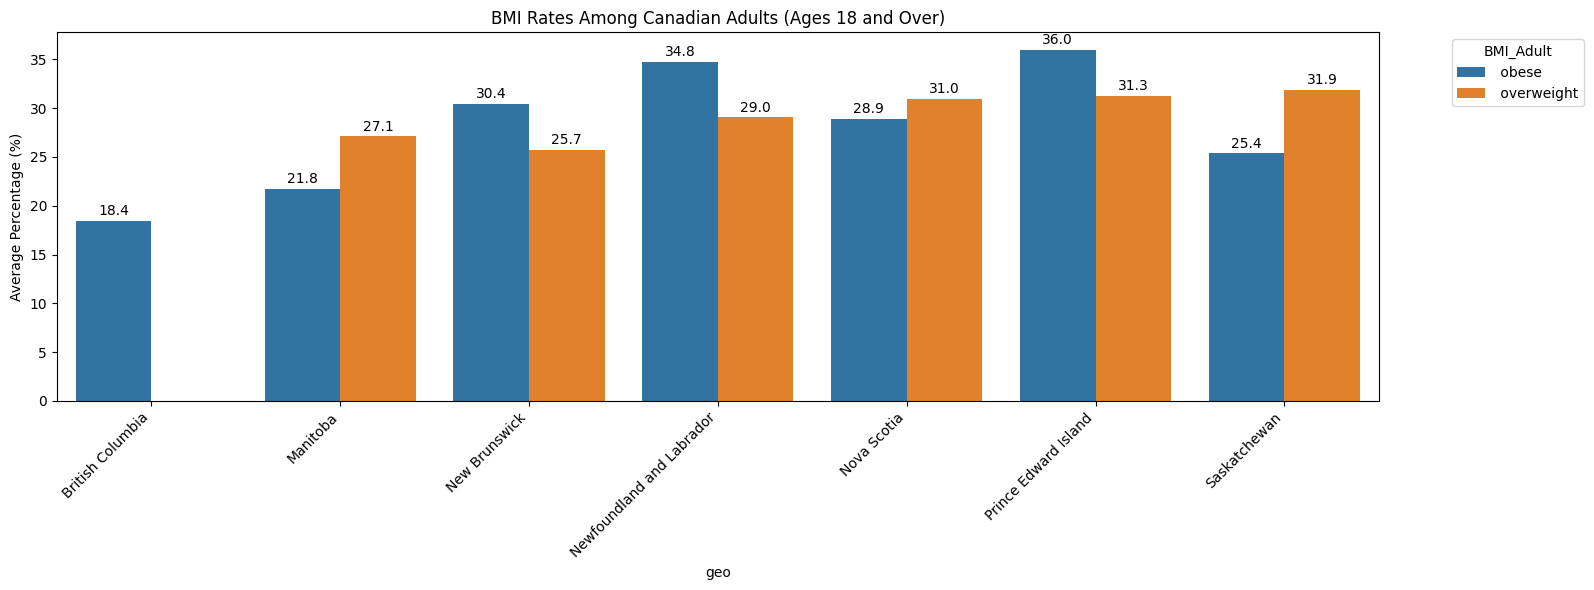

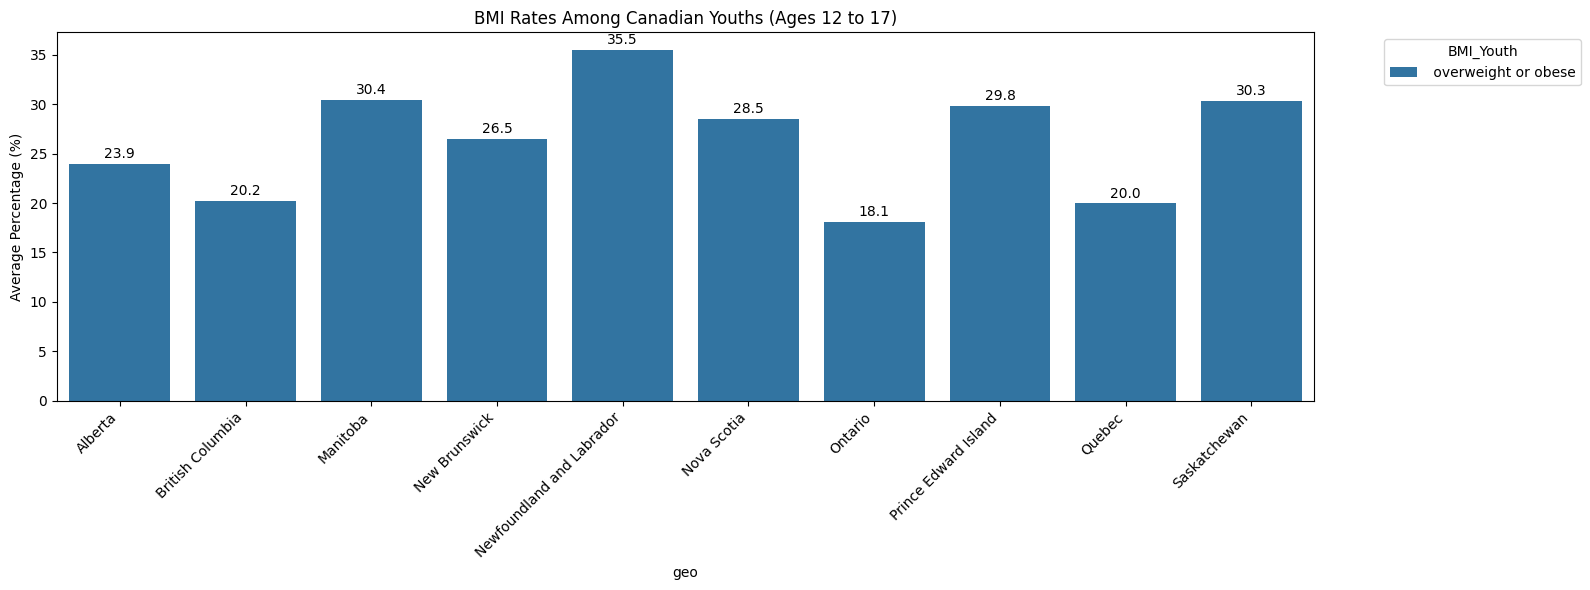

In [95]:
# plot BMI by Geographic Region
plot_bar_chart(percentages, 'geo', 'BMI_Adult', "BMI Rates Among Canadian Adults (Ages 18 and Over)", None, stacked_by=False, rotate=45)
plot_bar_chart(percentages, 'geo', 'BMI_Youth', "BMI Rates Among Canadian Youths (Ages 12 to 17)", None, stacked_by=False, rotate=45)

> Counts

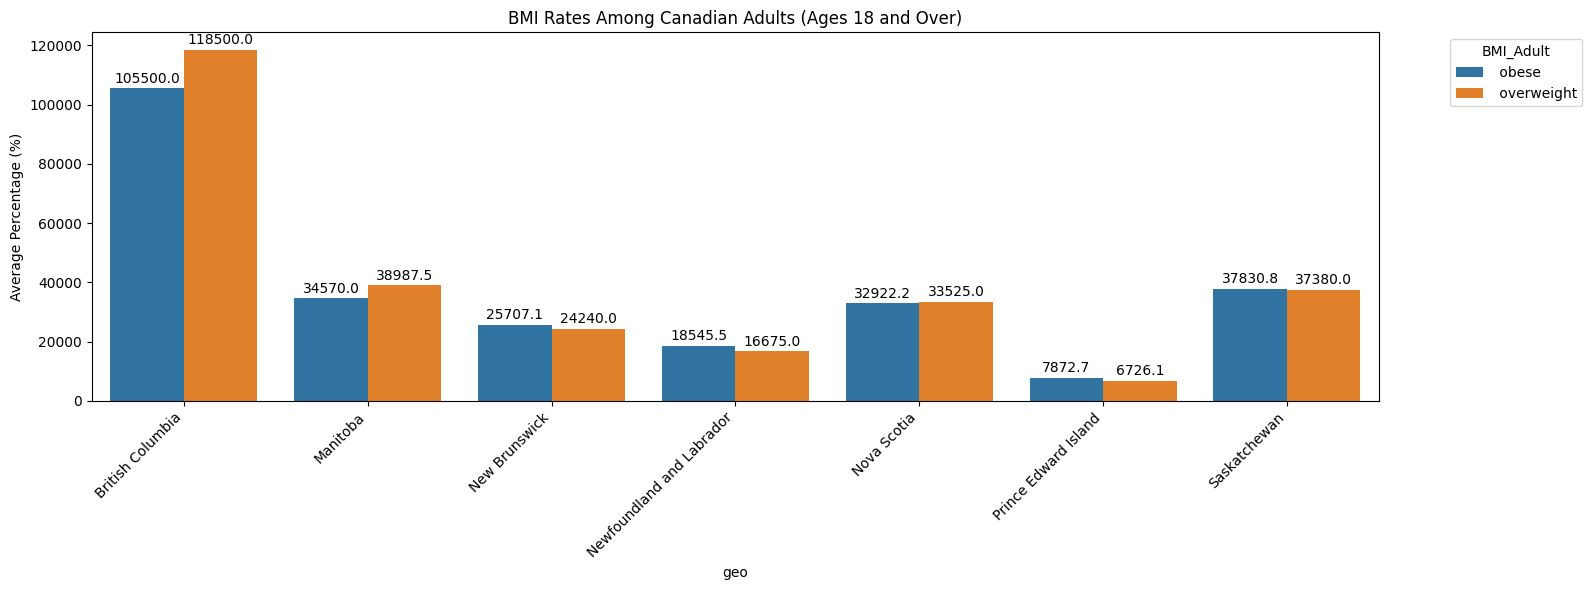

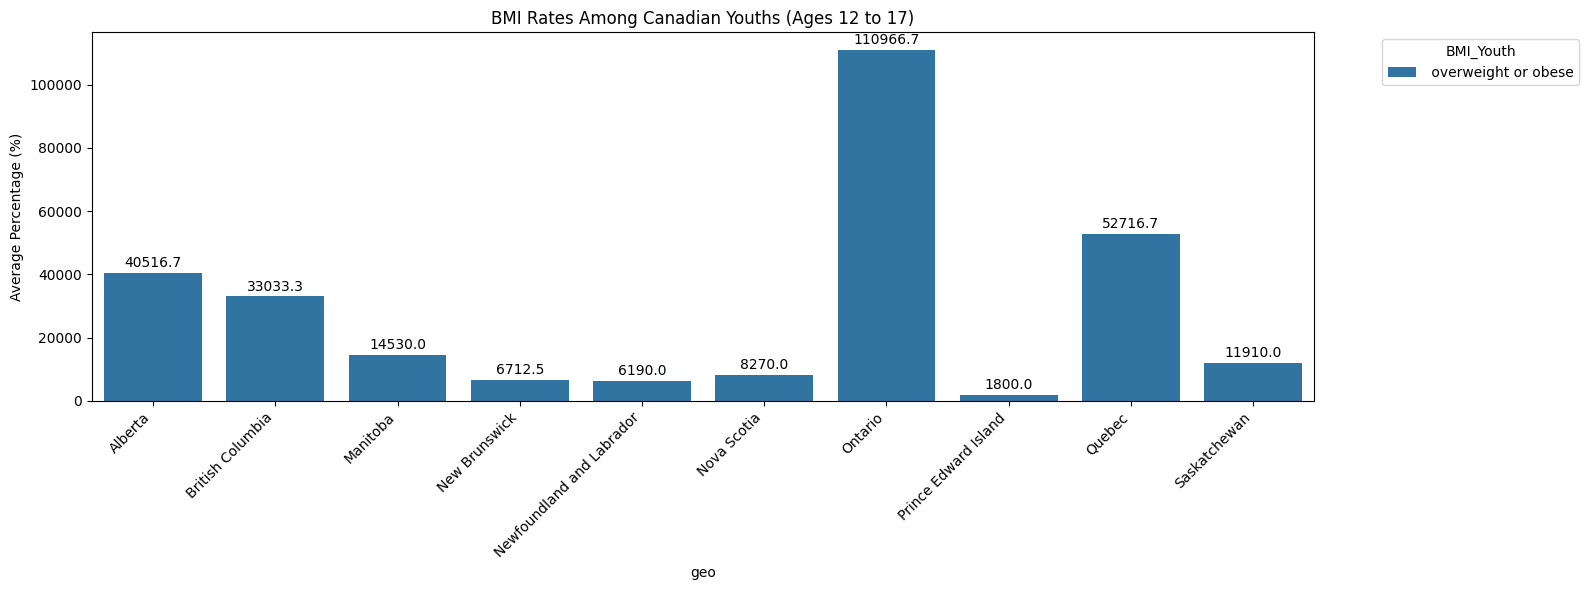

In [96]:
# plot BMI by Geographic Region
plot_bar_chart(counts, 'geo', 'BMI_Adult', "BMI Rates Among Canadian Adults (Ages 18 and Over)", None, stacked_by=False, rotate=45)
plot_bar_chart(counts, 'geo', 'BMI_Youth', "BMI Rates Among Canadian Youths (Ages 12 to 17)", None, stacked_by=False, rotate=45)

# BMI by Gender

> Percentages

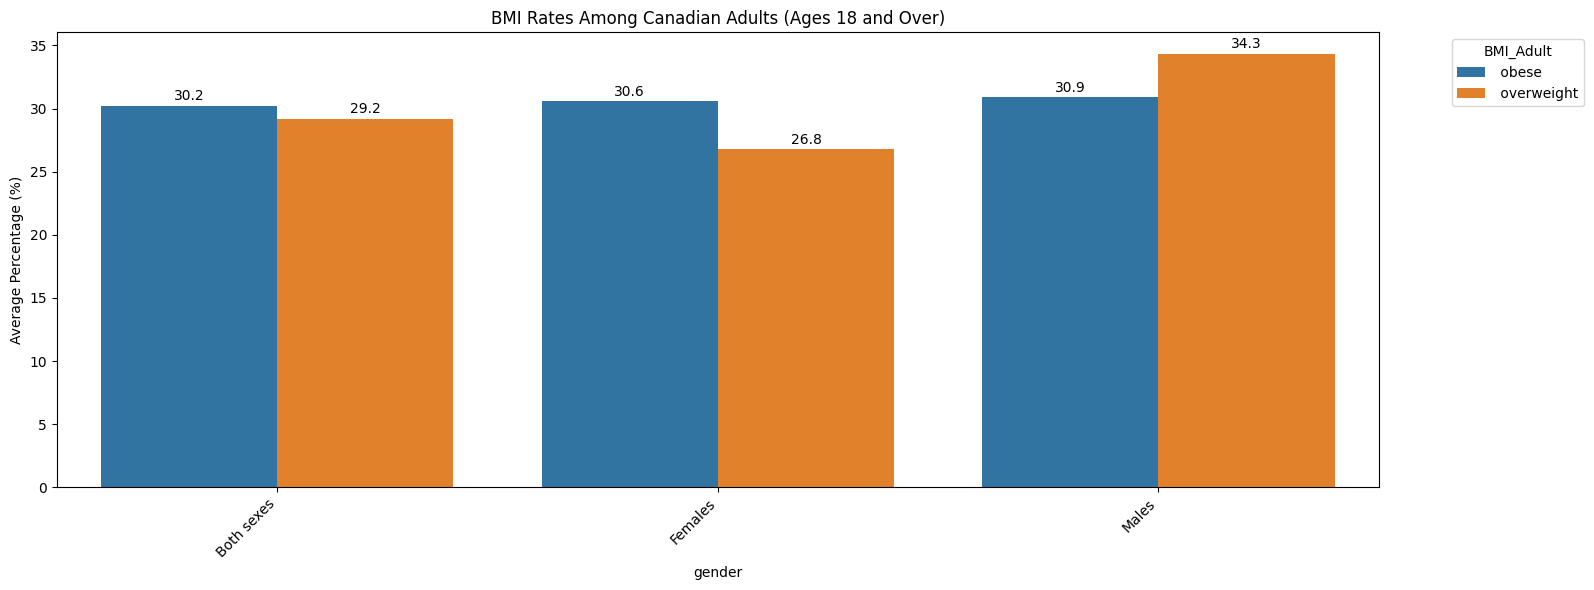

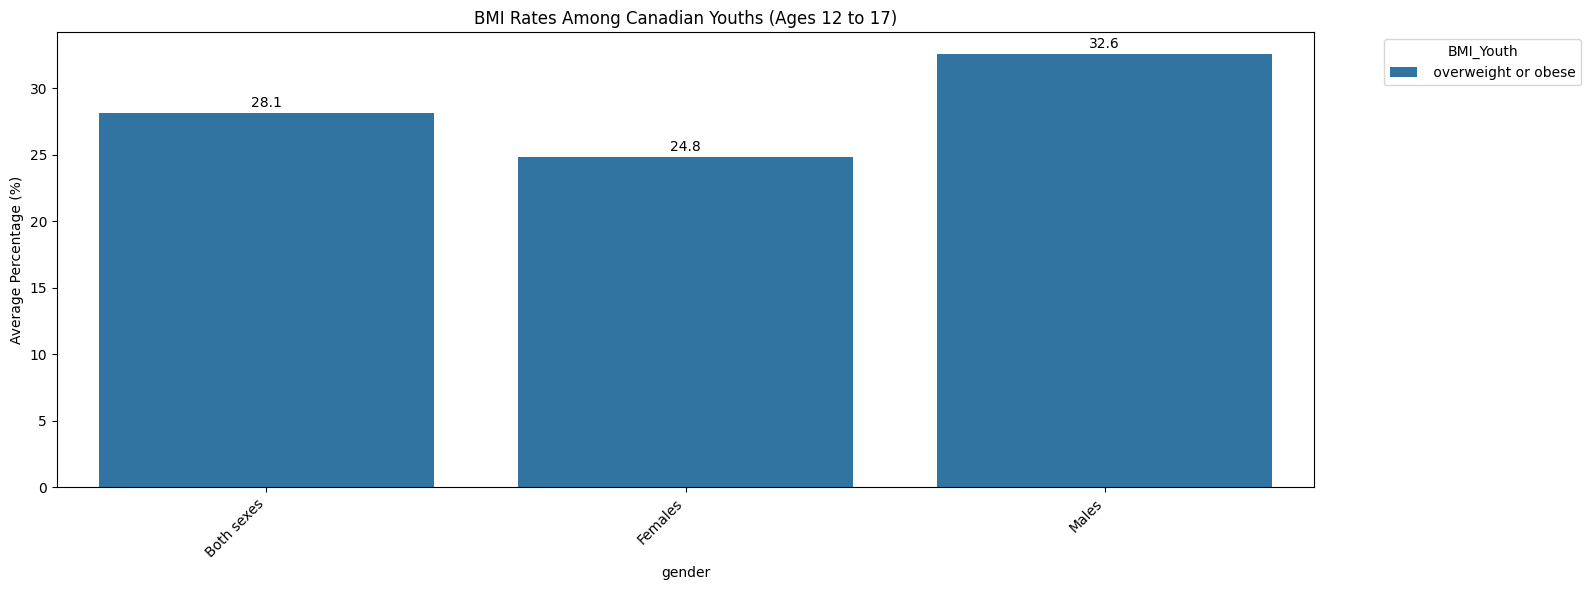

In [97]:
# plot BMI by Genger
plot_bar_chart(percentages, 'gender', 'BMI_Adult', "BMI Rates Among Canadian Adults (Ages 18 and Over)", None, stacked_by=False, rotate=45)
plot_bar_chart(percentages, 'gender', 'BMI_Youth', "BMI Rates Among Canadian Youths (Ages 12 to 17)", None, stacked_by=False, rotate=45)

> Counts

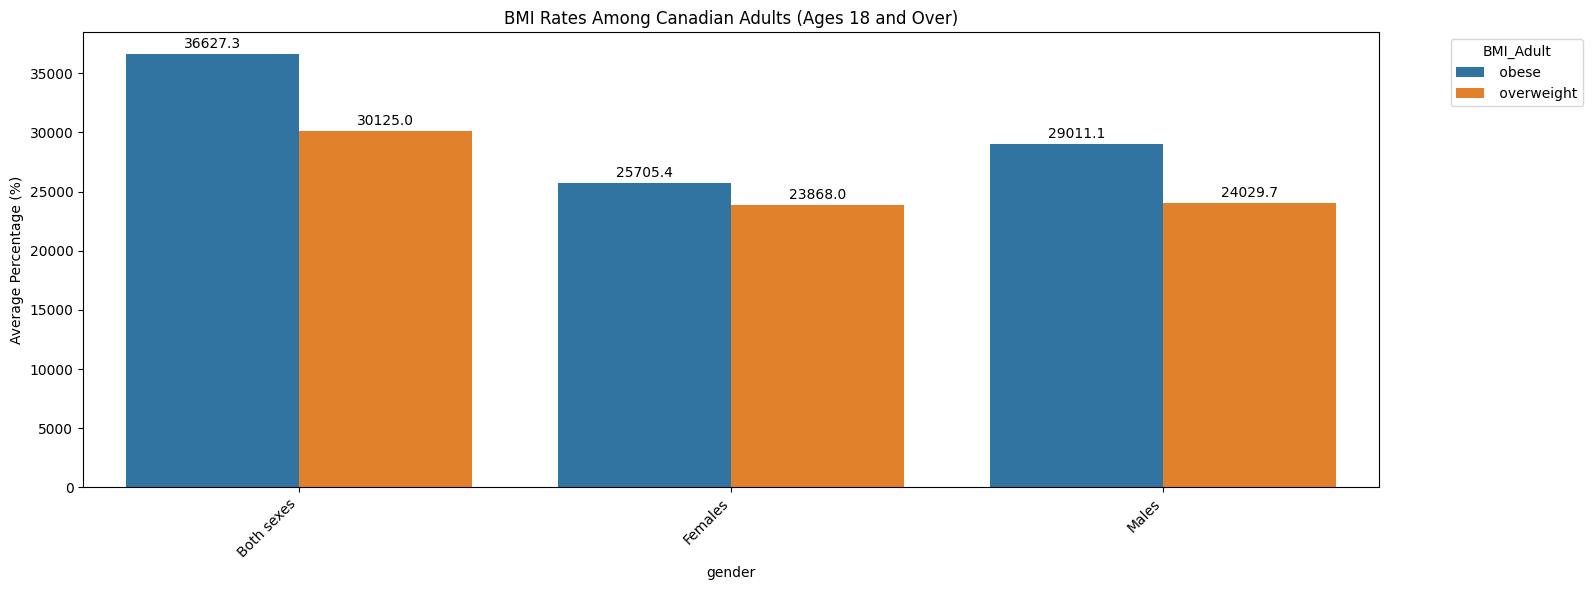

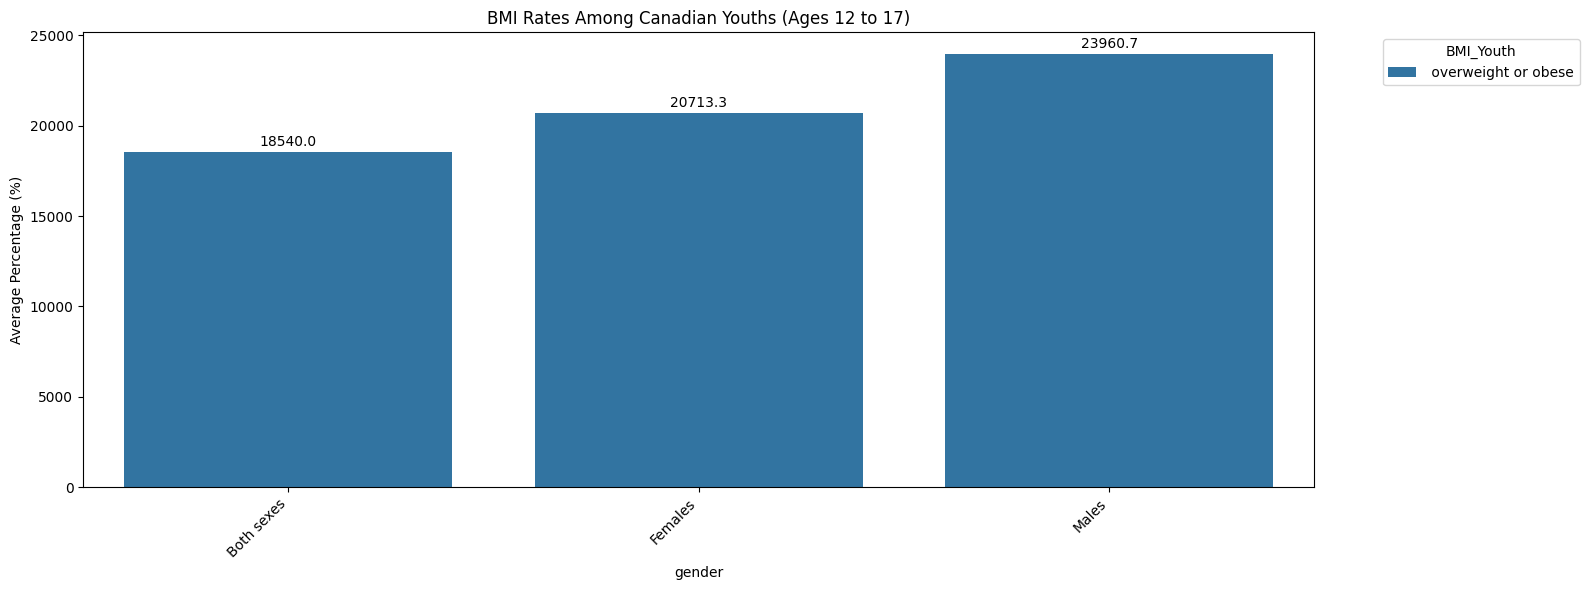

In [98]:
# plot BMI by Genger
plot_bar_chart(counts, 'gender', 'BMI_Adult', "BMI Rates Among Canadian Adults (Ages 18 and Over)", None, stacked_by=False, rotate=45)
plot_bar_chart(counts, 'gender', 'BMI_Youth', "BMI Rates Among Canadian Youths (Ages 12 to 17)", None, stacked_by=False, rotate=45)

# Plots by Gender

In [99]:
df.columns

Index(['ref_date', 'geo', 'age_group', 'gender', 'unit', 'value', 'status',
       'Belonging', 'Immunization', 'Life_Stress', 'Smoking_Status',
       'Nutrition', 'Life_Satisfaction', 'Chronic_Condition',
       'Healthcare_Provider', 'Perceived_Mental_Health', 'Alcohol_Drug_Use',
       'Vaping', 'Perceived_Health', 'Physical_Activity', 'BMI_Adult',
       'Breastfeeding', 'BMI_Youth'],
      dtype='object')

In [100]:
cols_to_plot = ['Belonging', 'Immunization', 'Life_Stress', 'Smoking_Status',
       'Nutrition', 'Life_Satisfaction', 'Chronic_Condition',
       'Healthcare_Provider', 'Perceived_Mental_Health', 'Alcohol_Drug_Use',
       'Vaping', 'Perceived_Health', 'Physical_Activity', 'Breastfeeding']

> Percentages

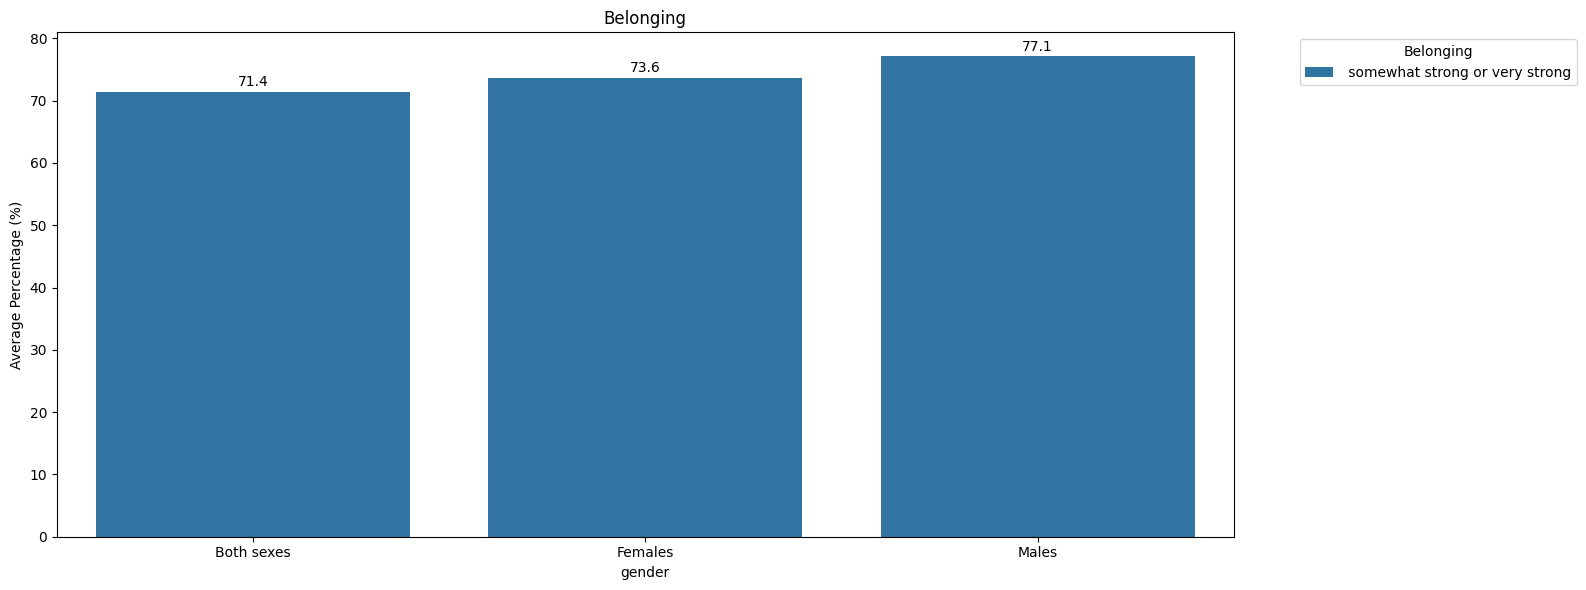

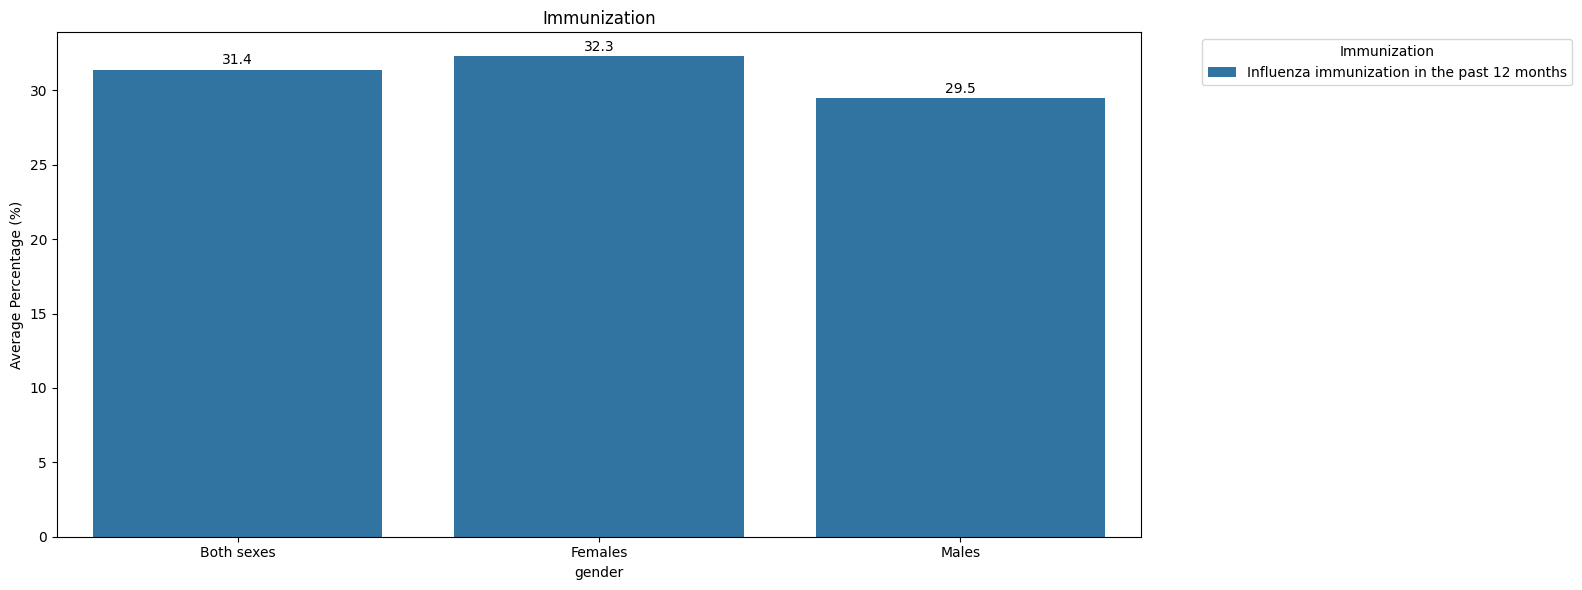

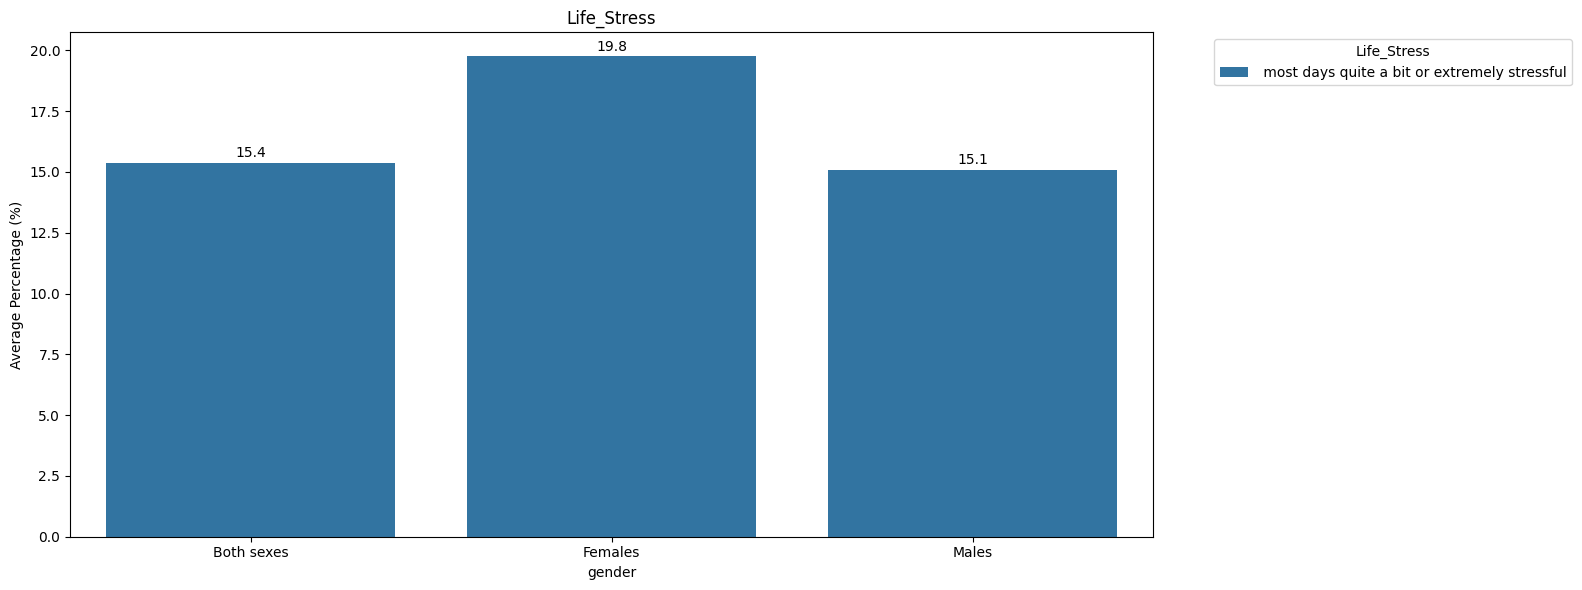

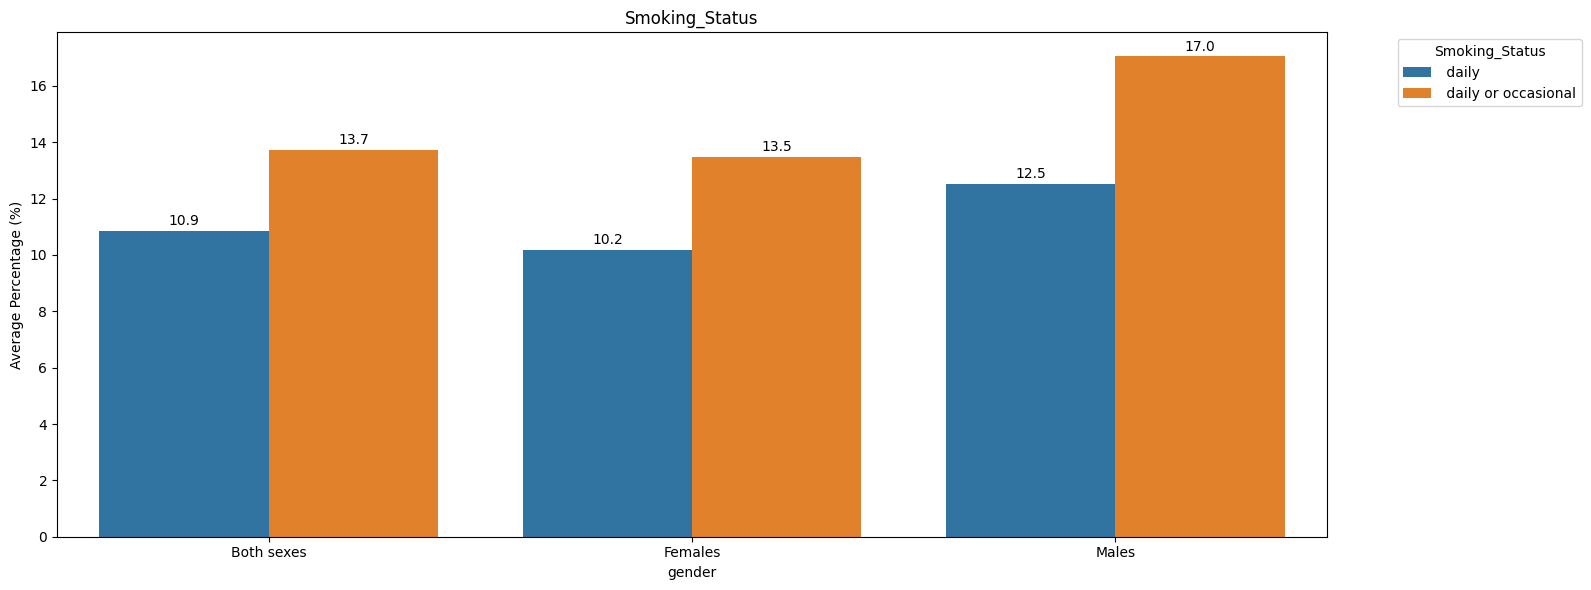

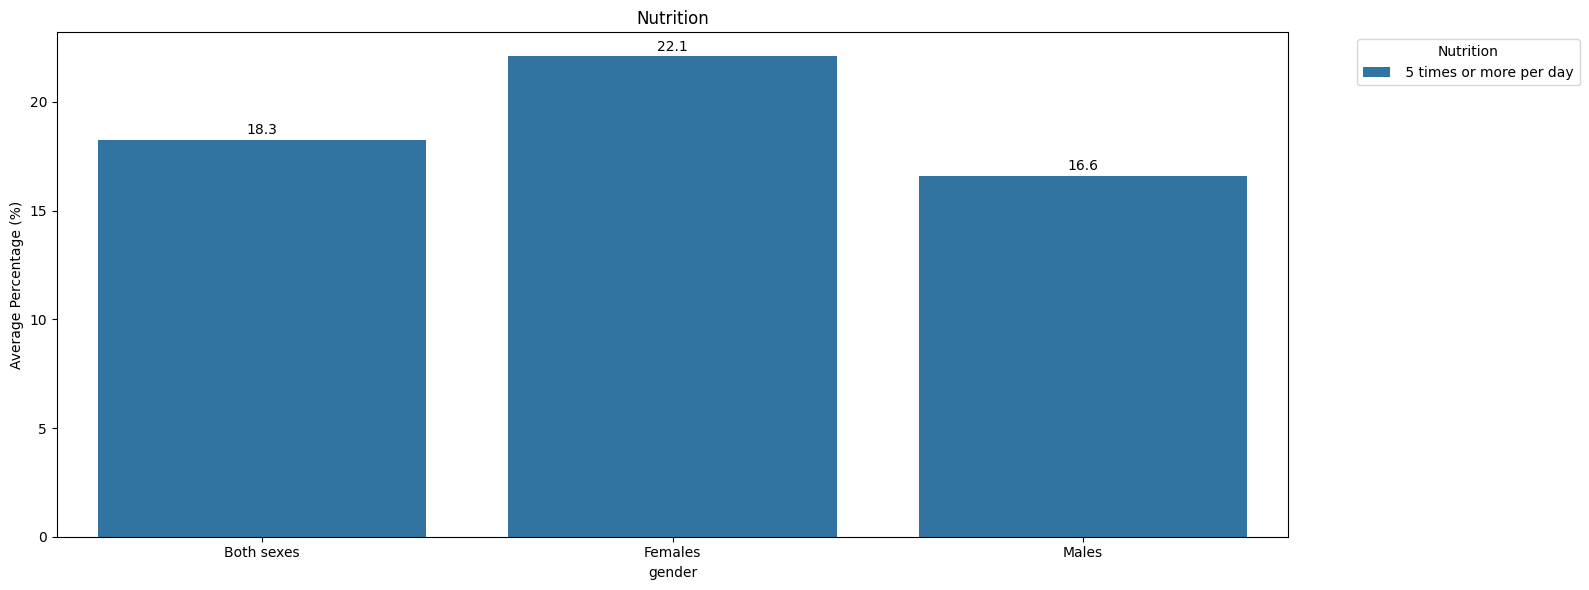

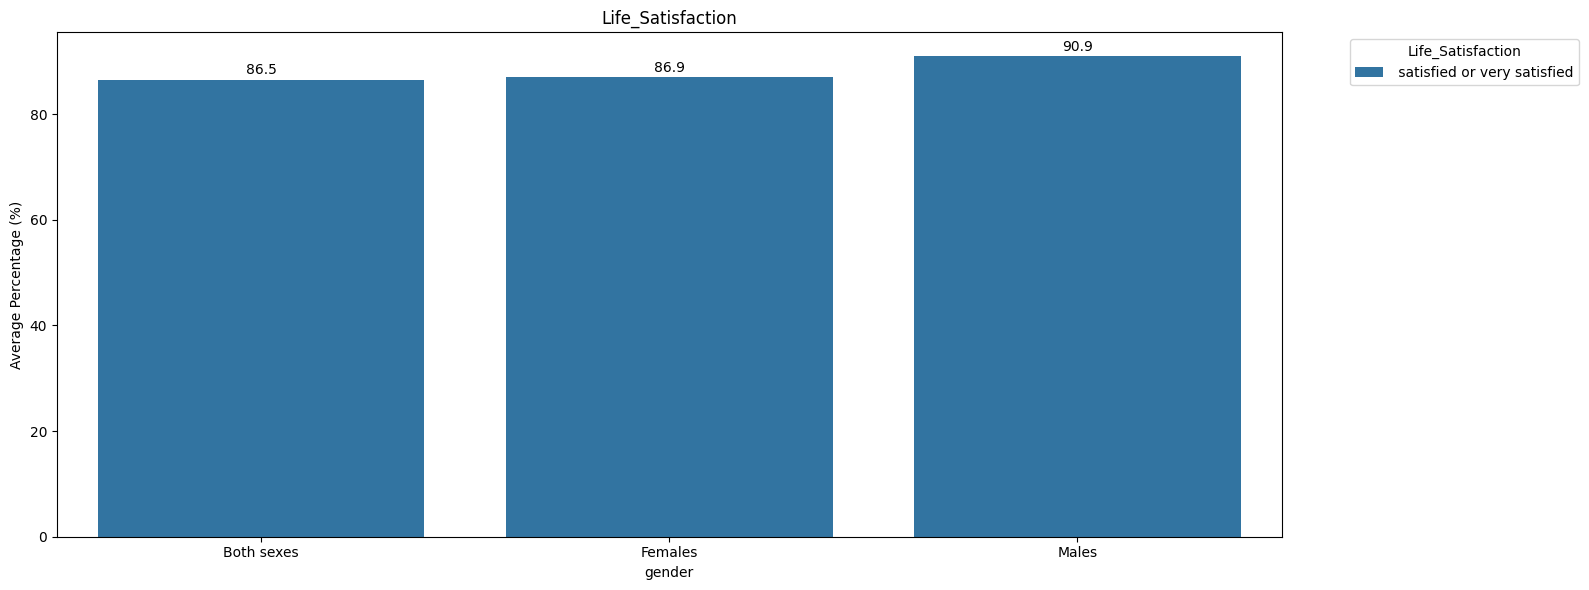

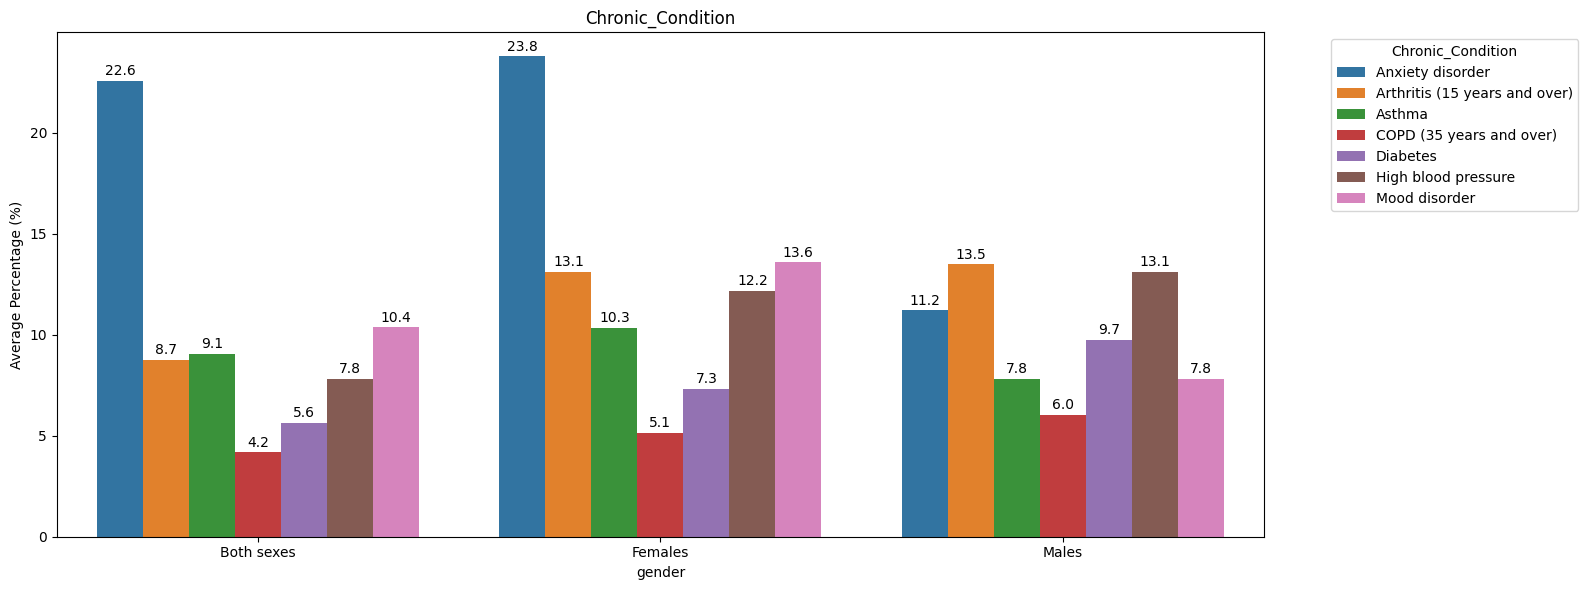

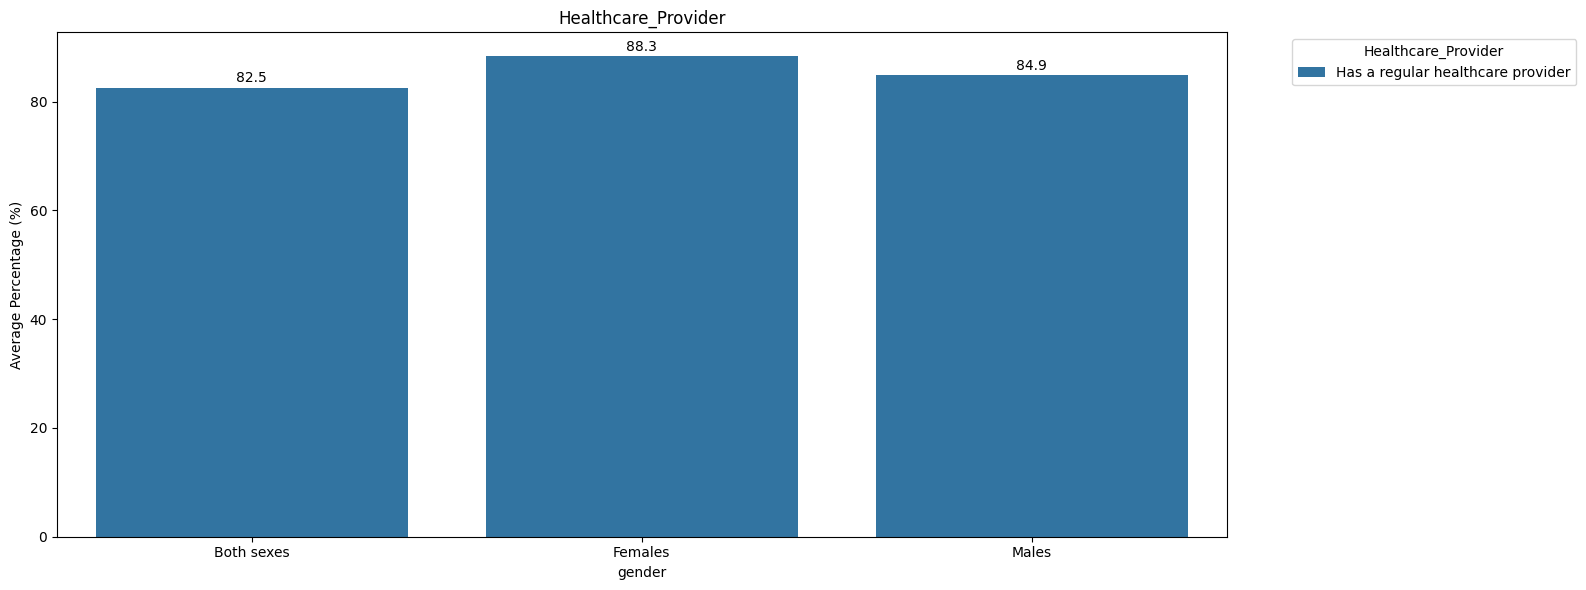

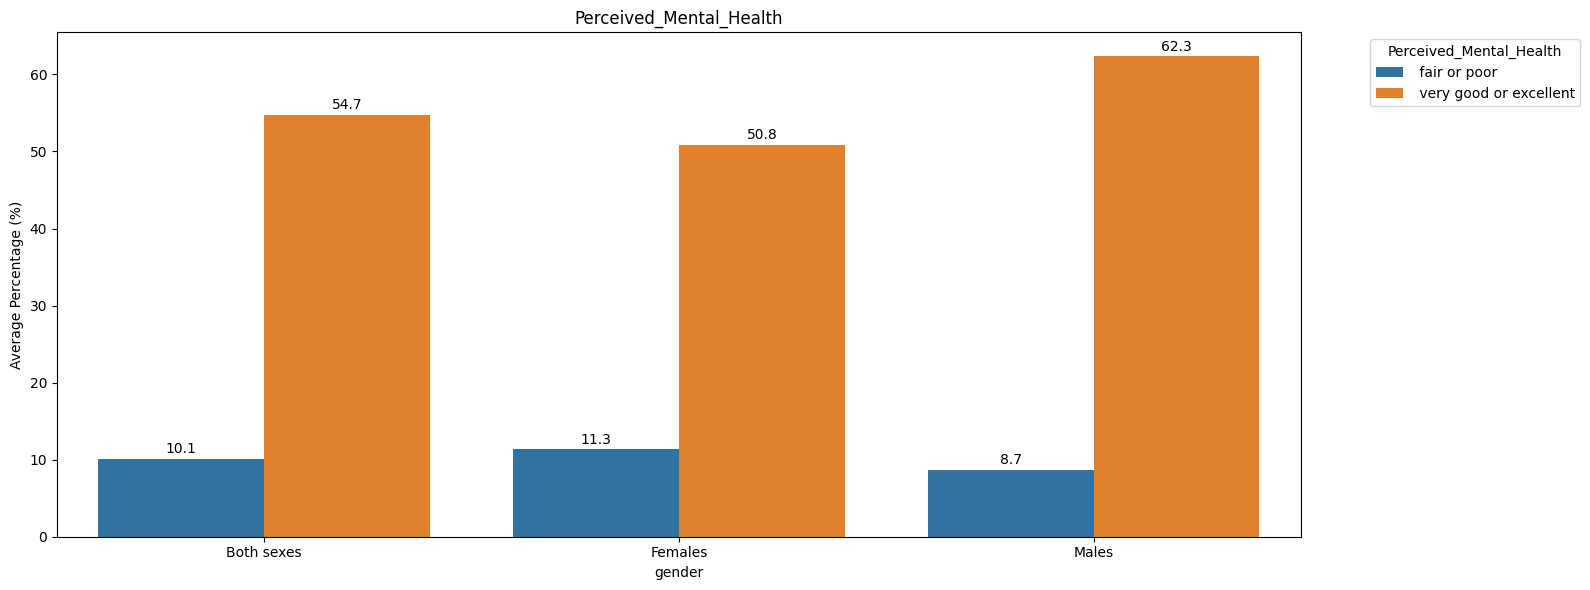

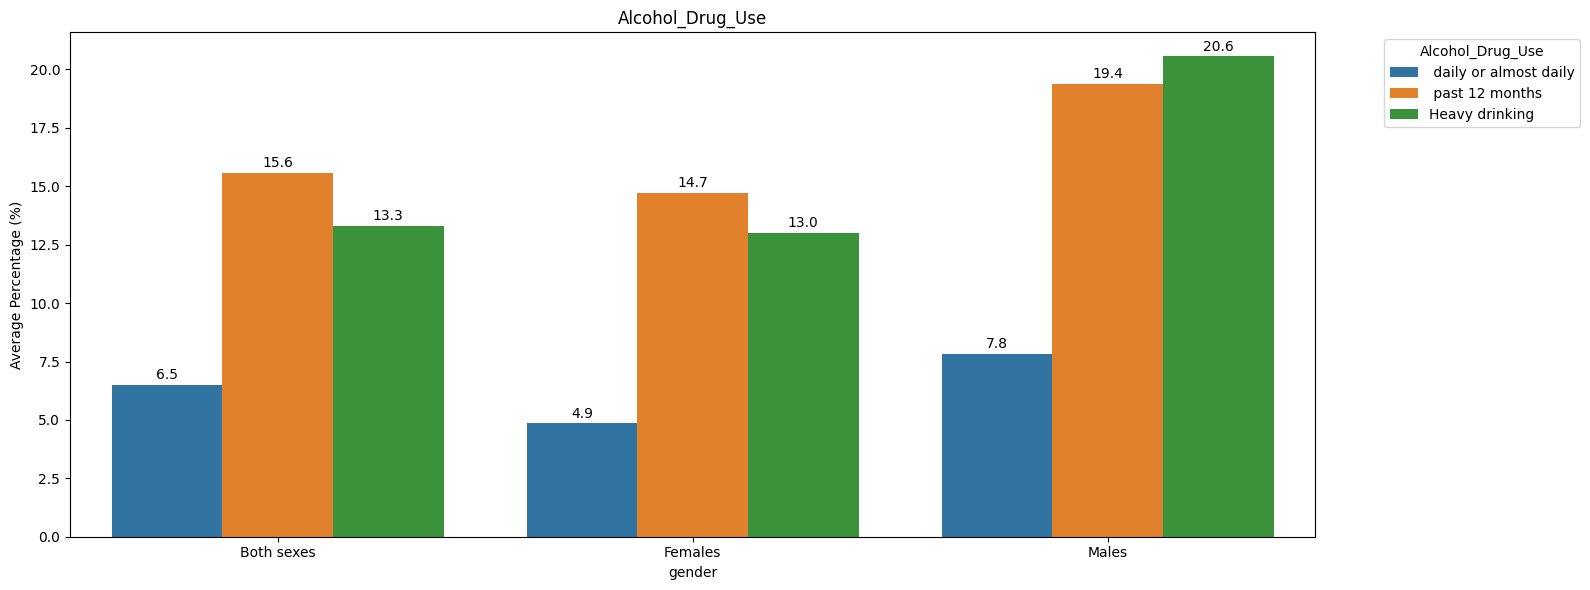

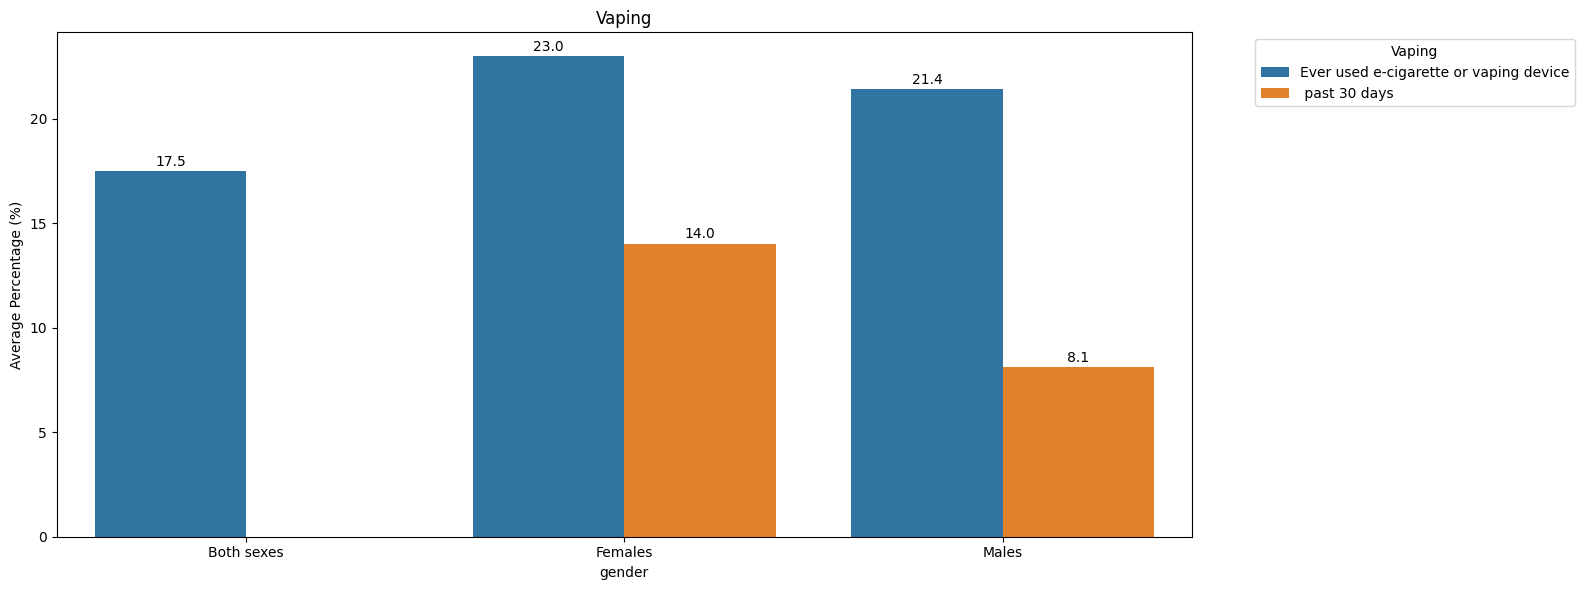

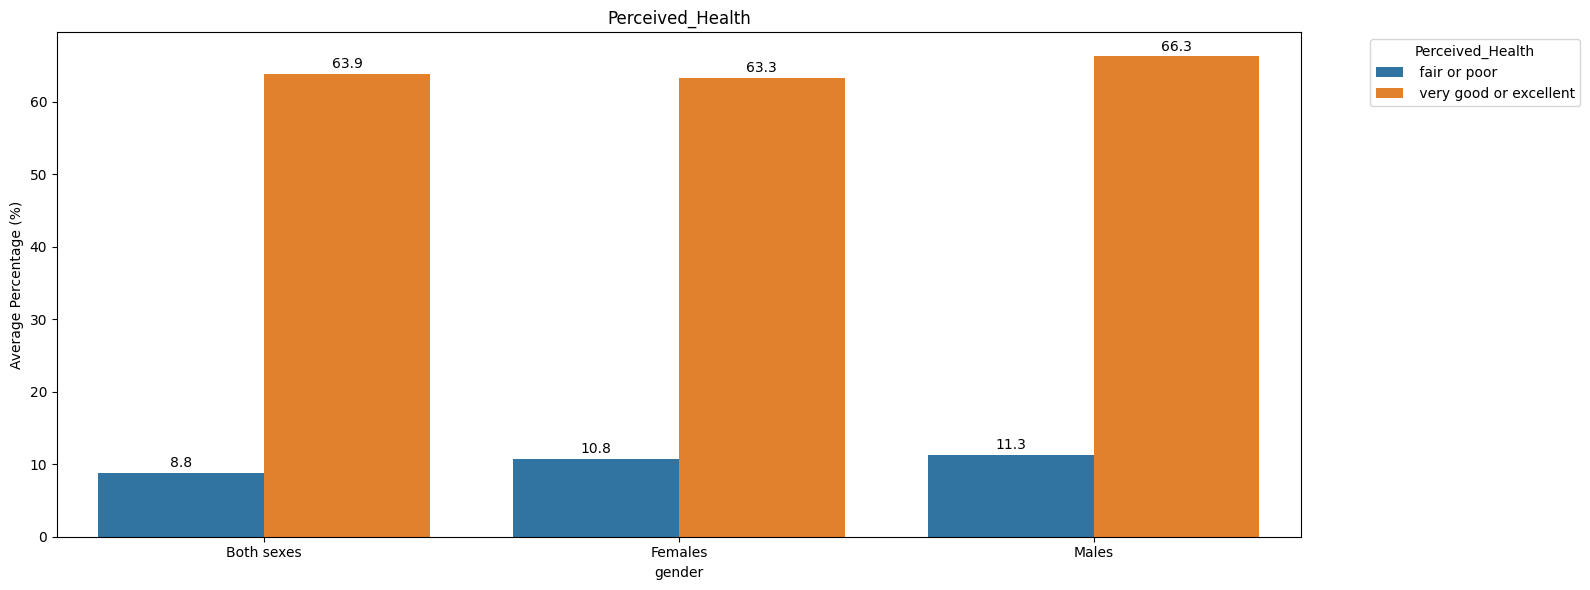

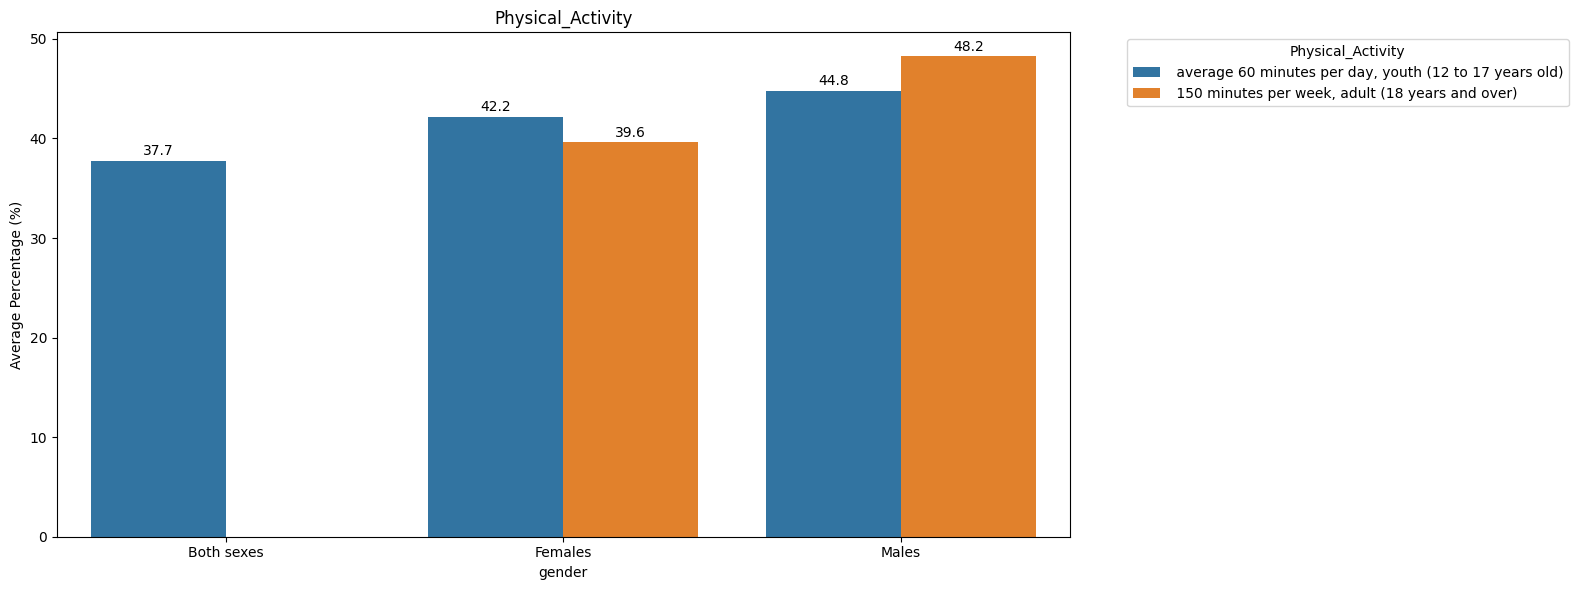

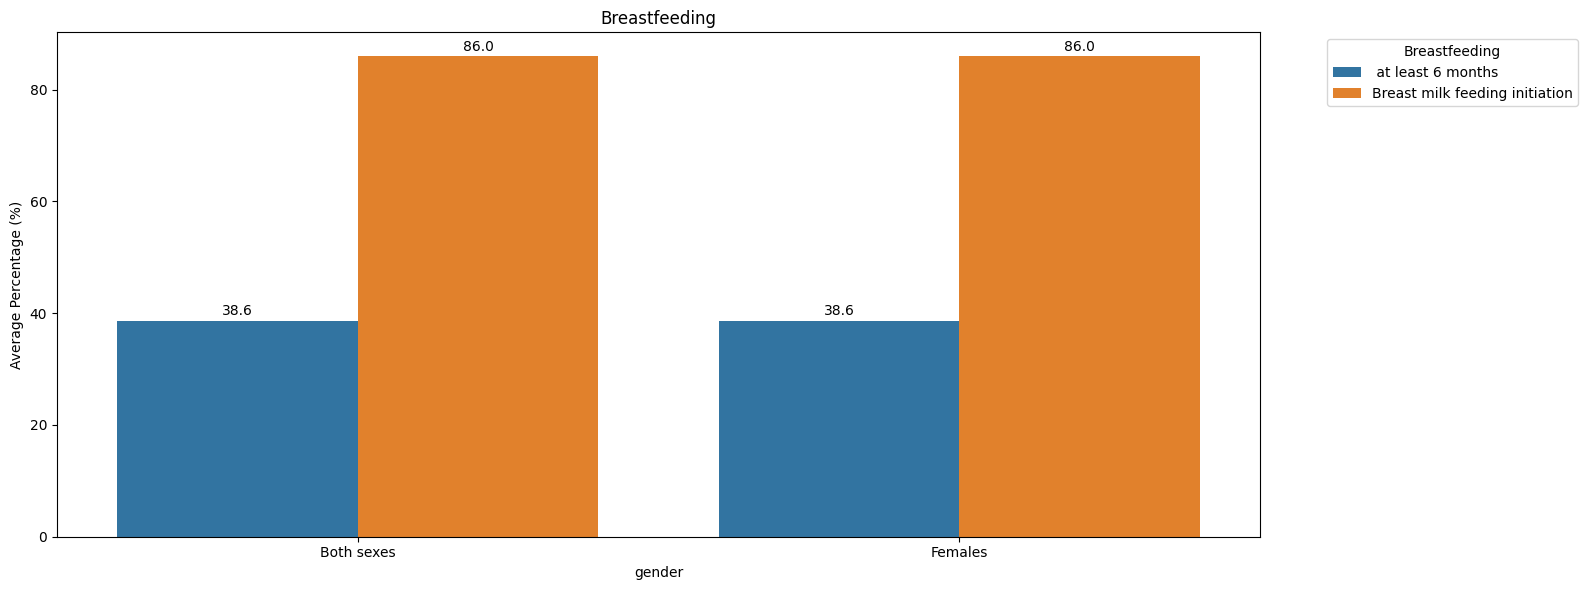

In [101]:
# Plot by Gender
for col in cols_to_plot:
    plot_bar_chart(percentages, 'gender', col, col, stacked_by=False)

> Counts

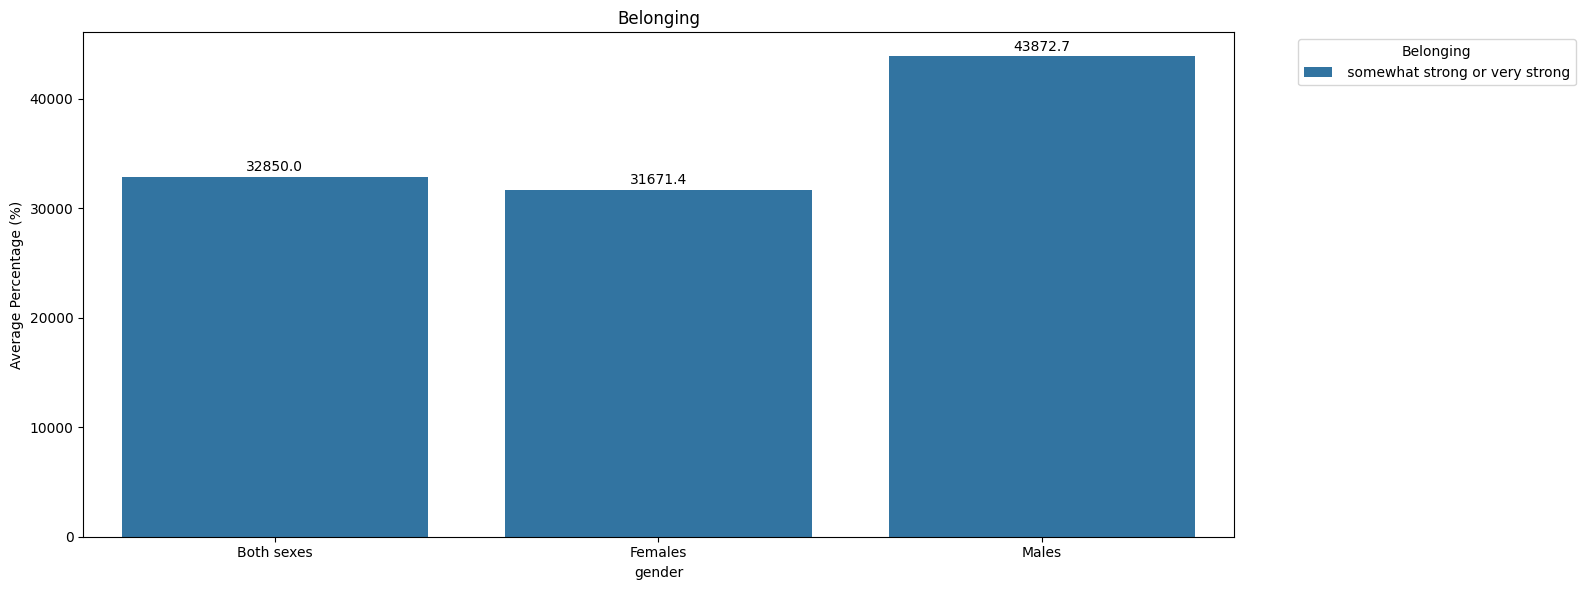

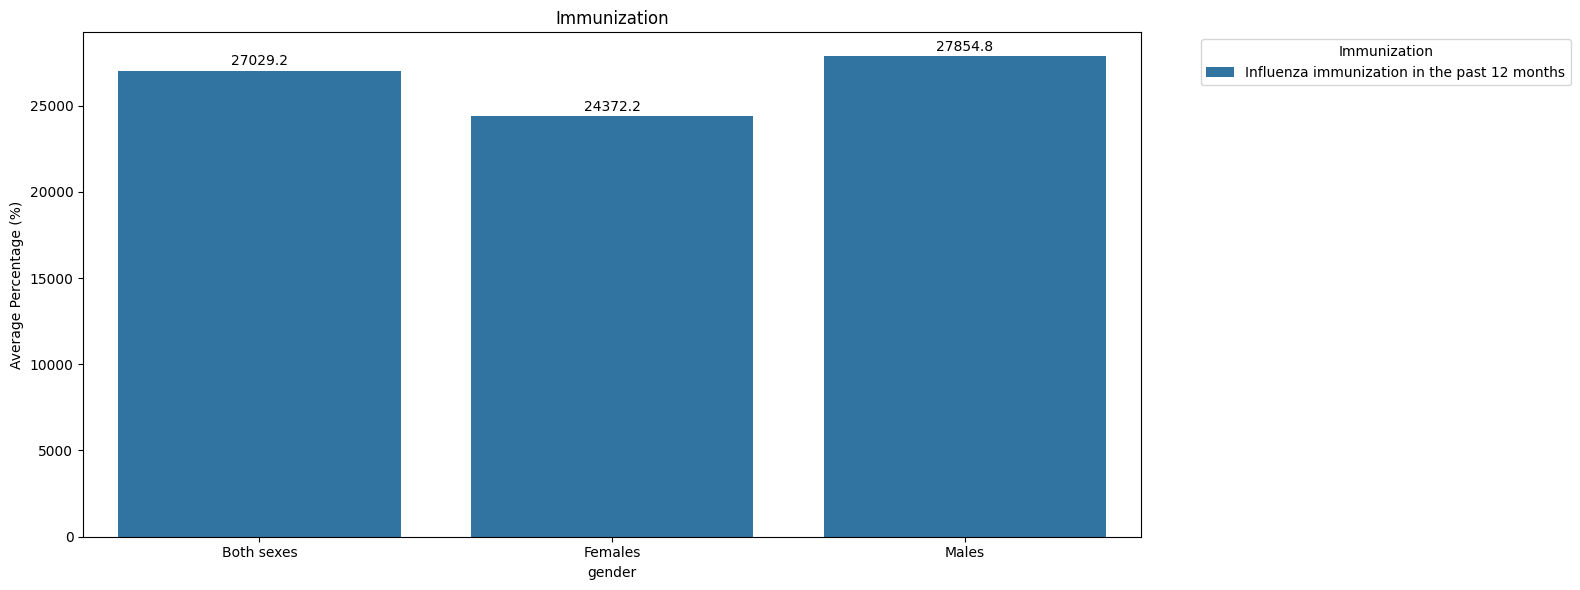

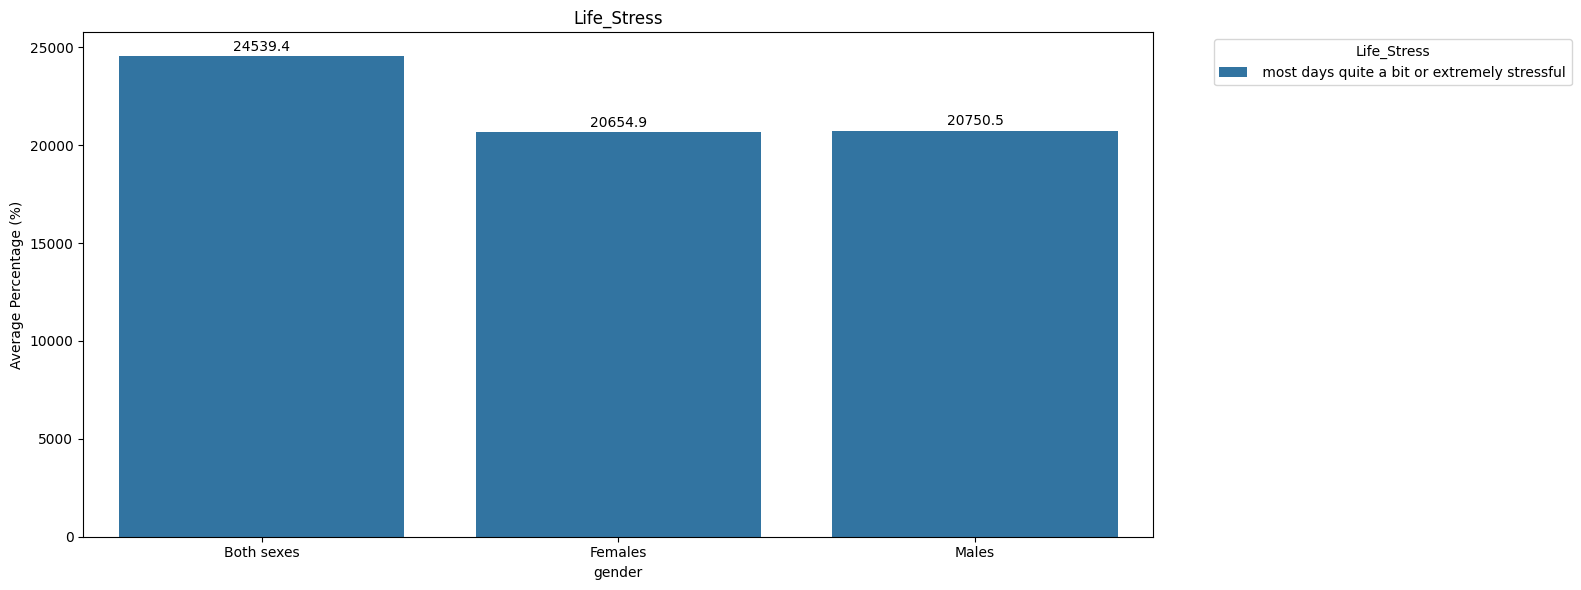

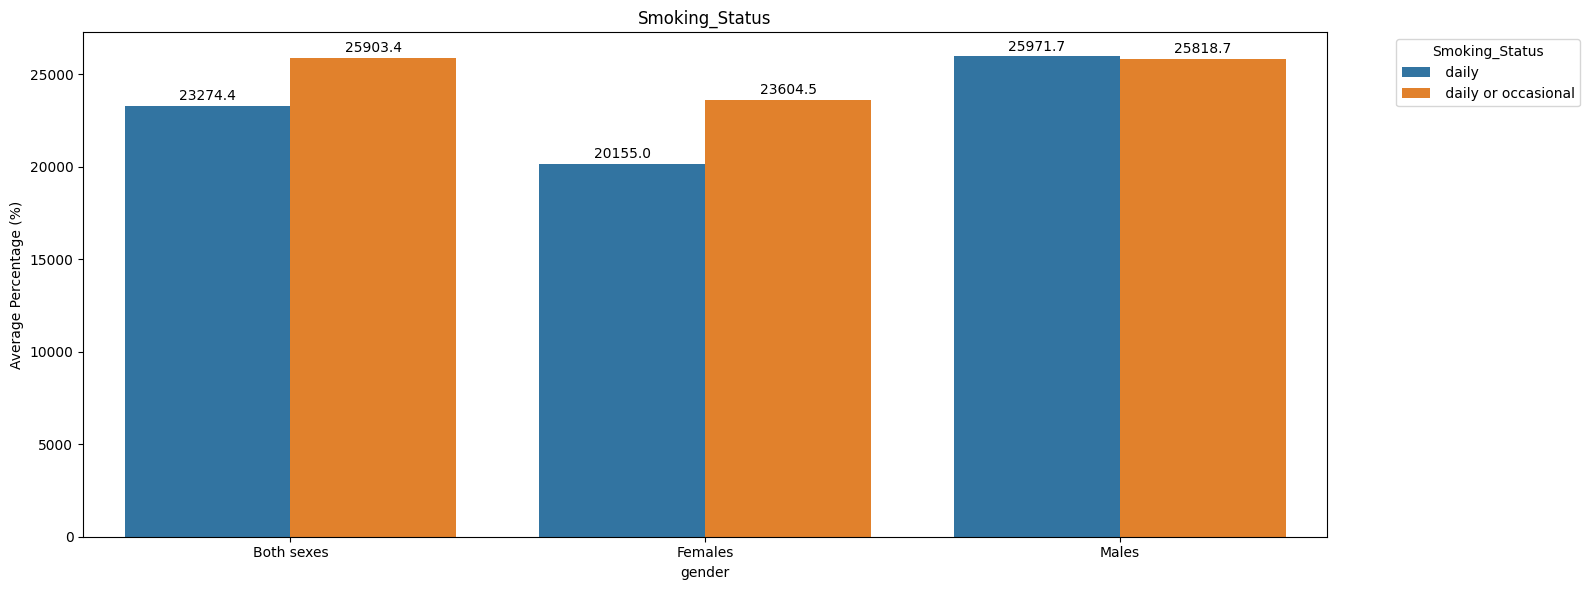

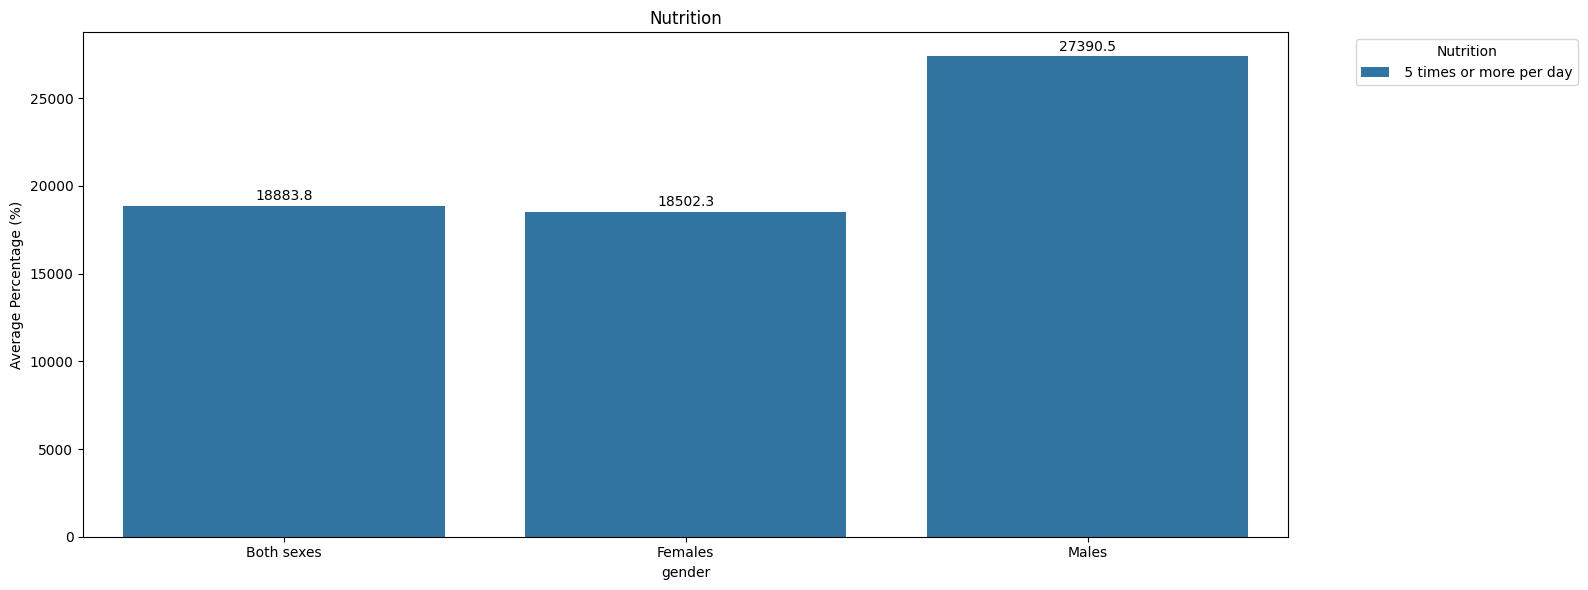

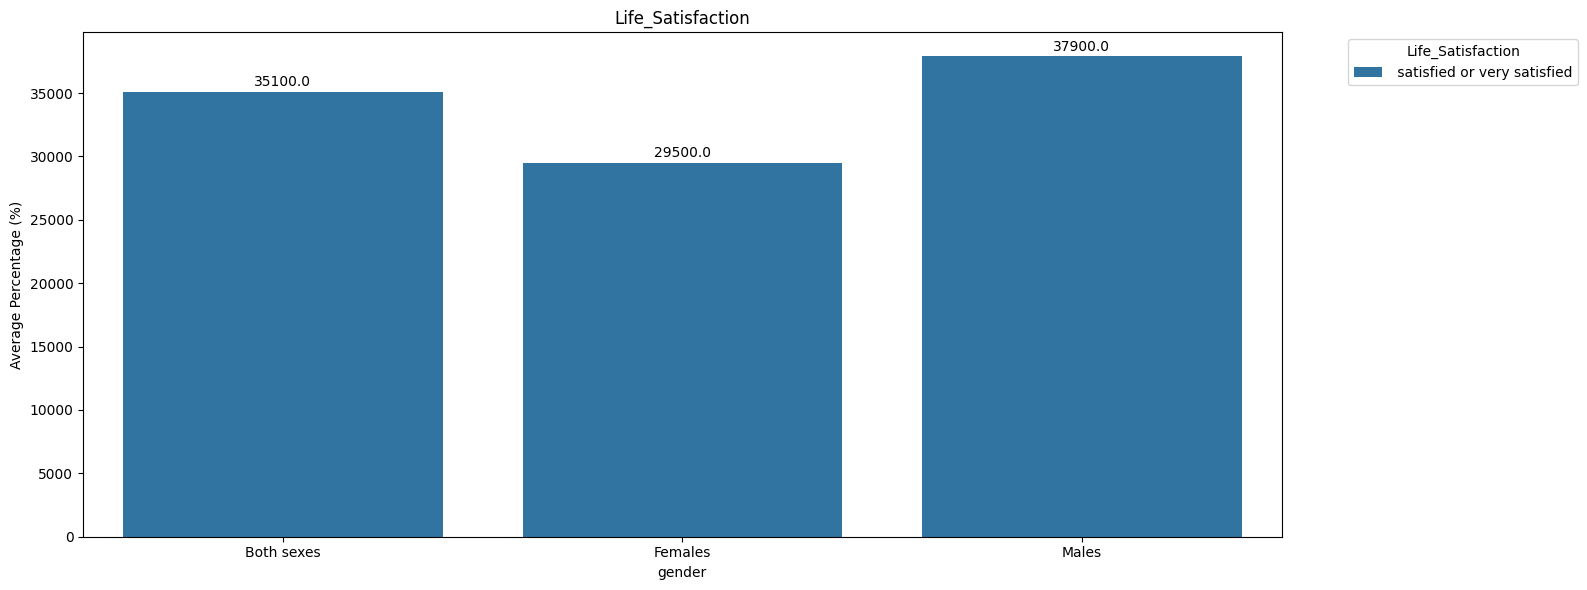

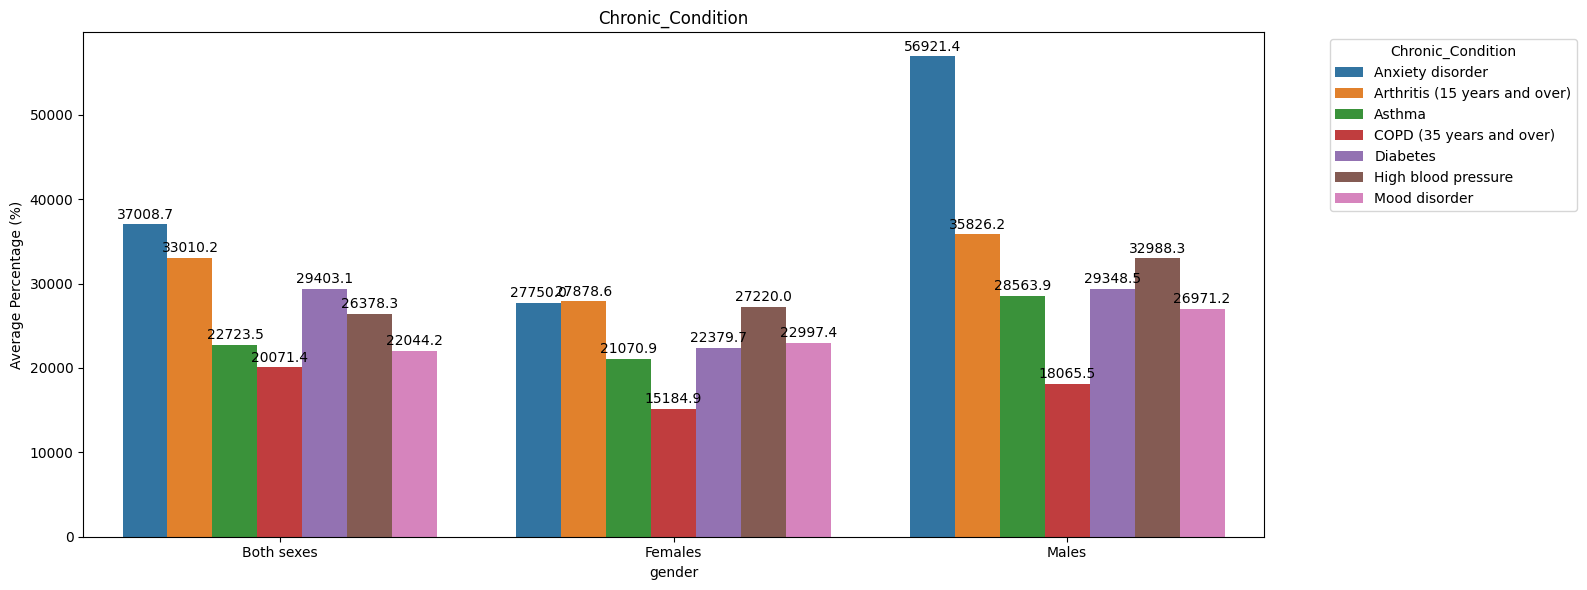

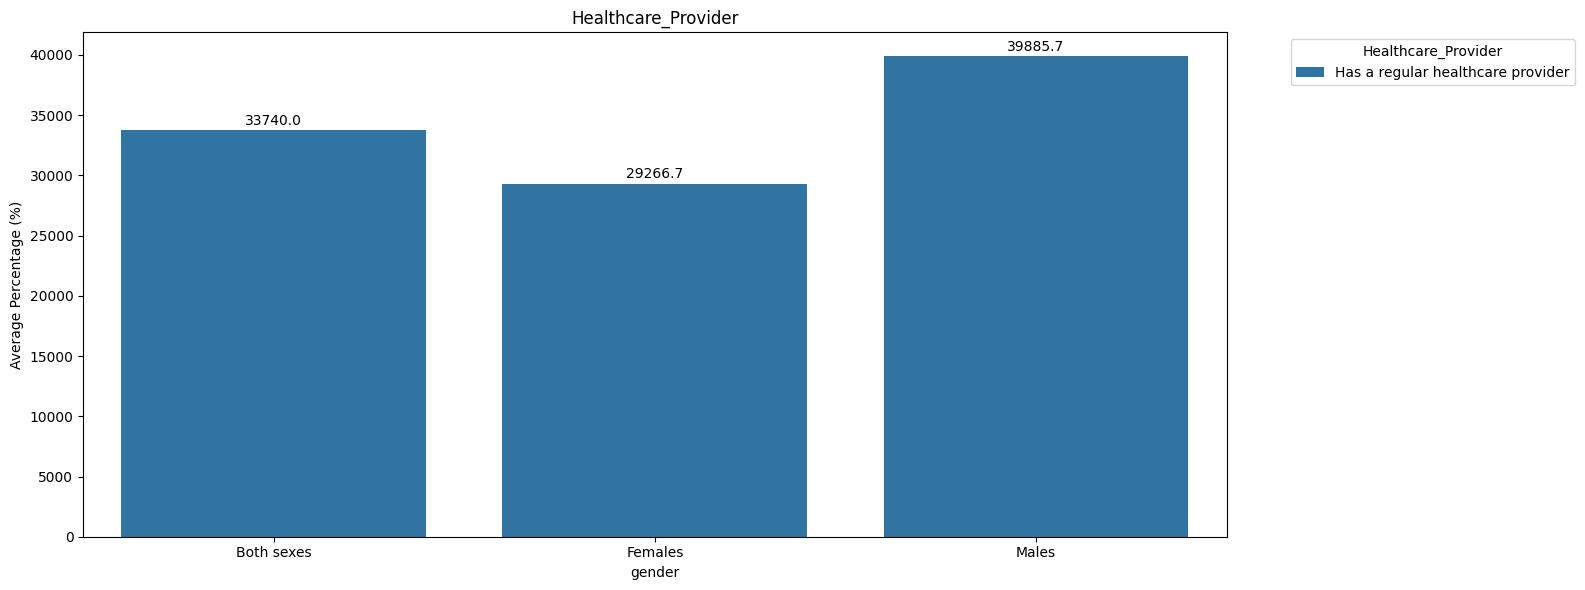

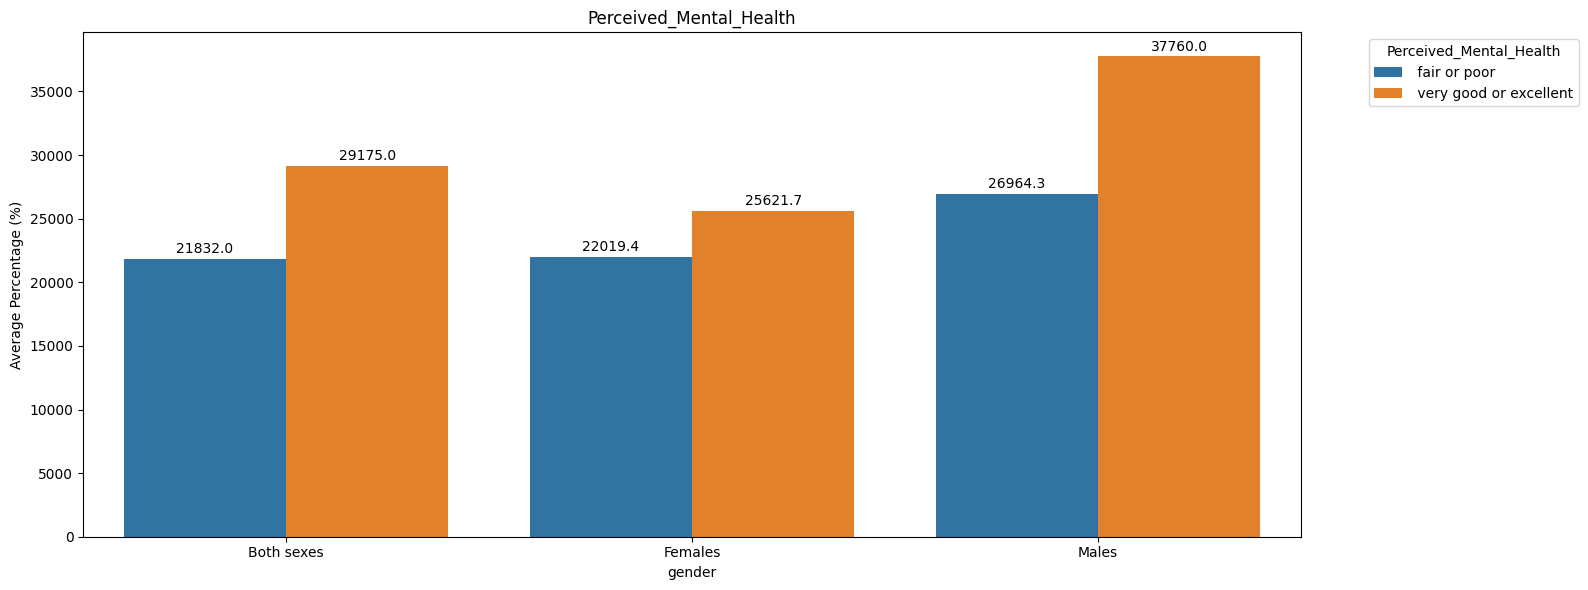

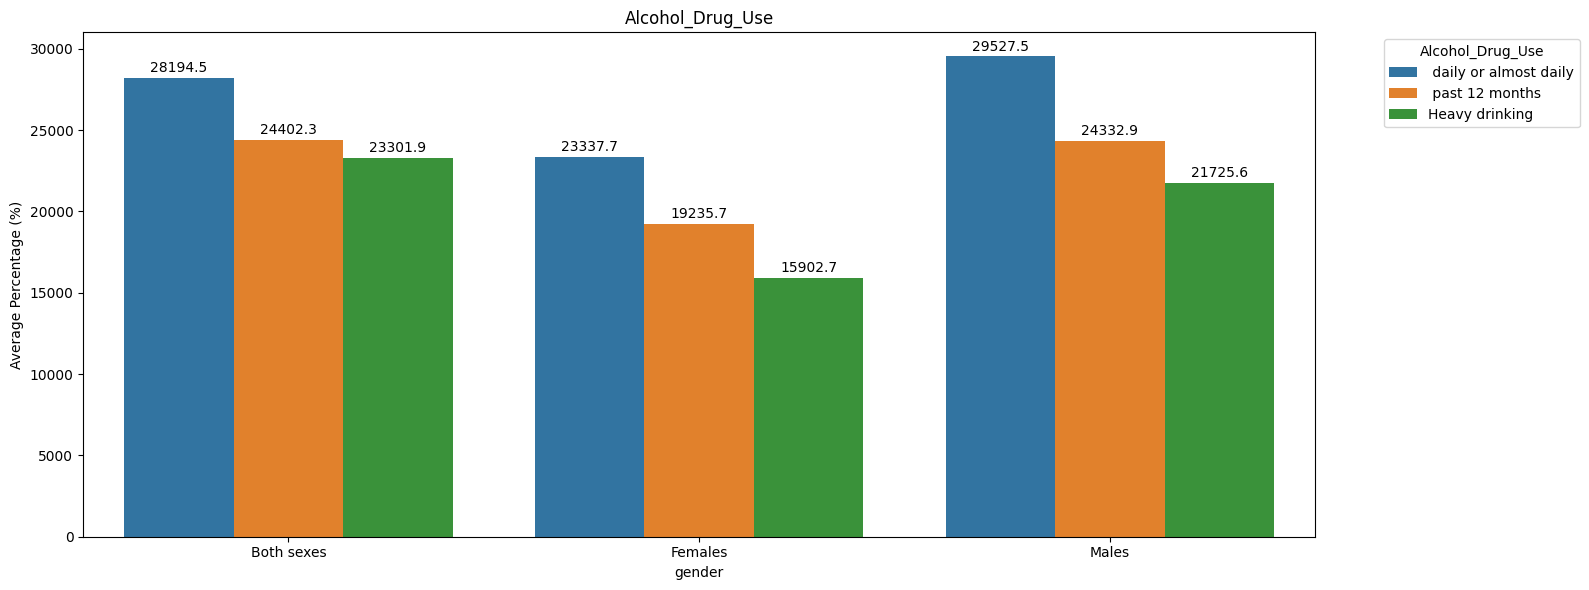

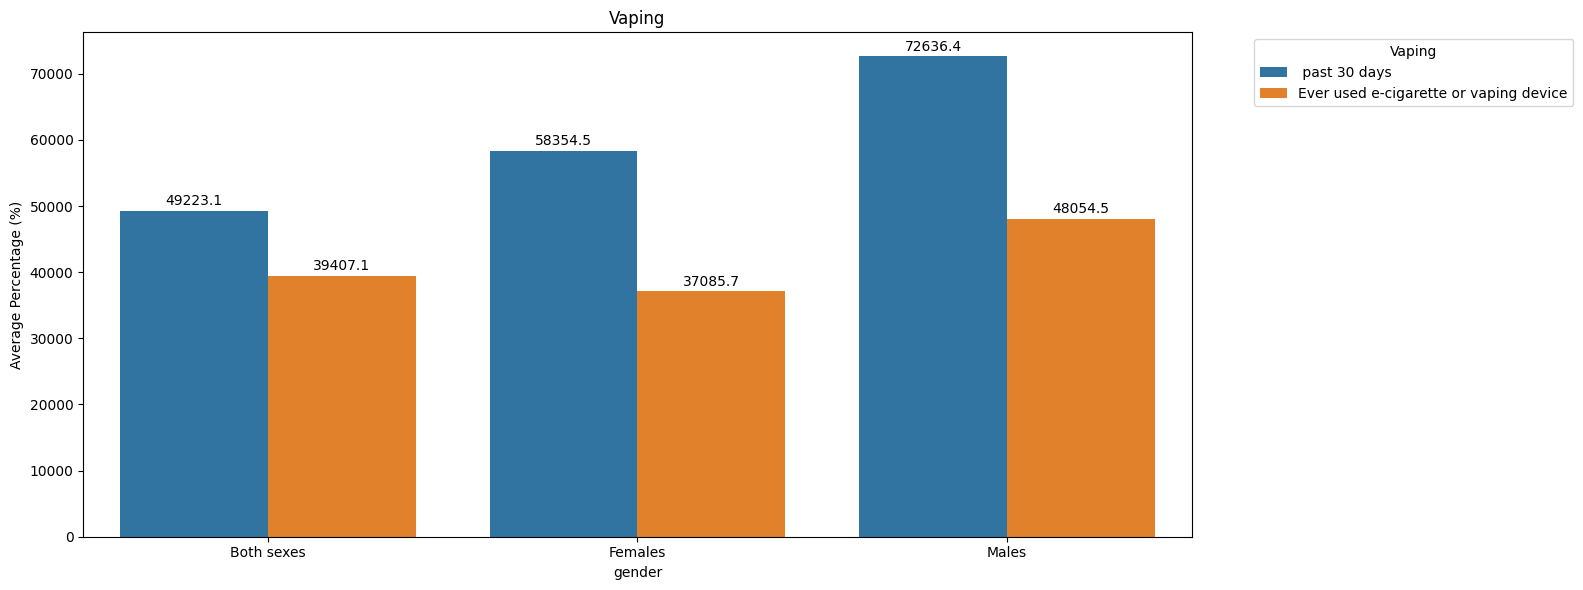

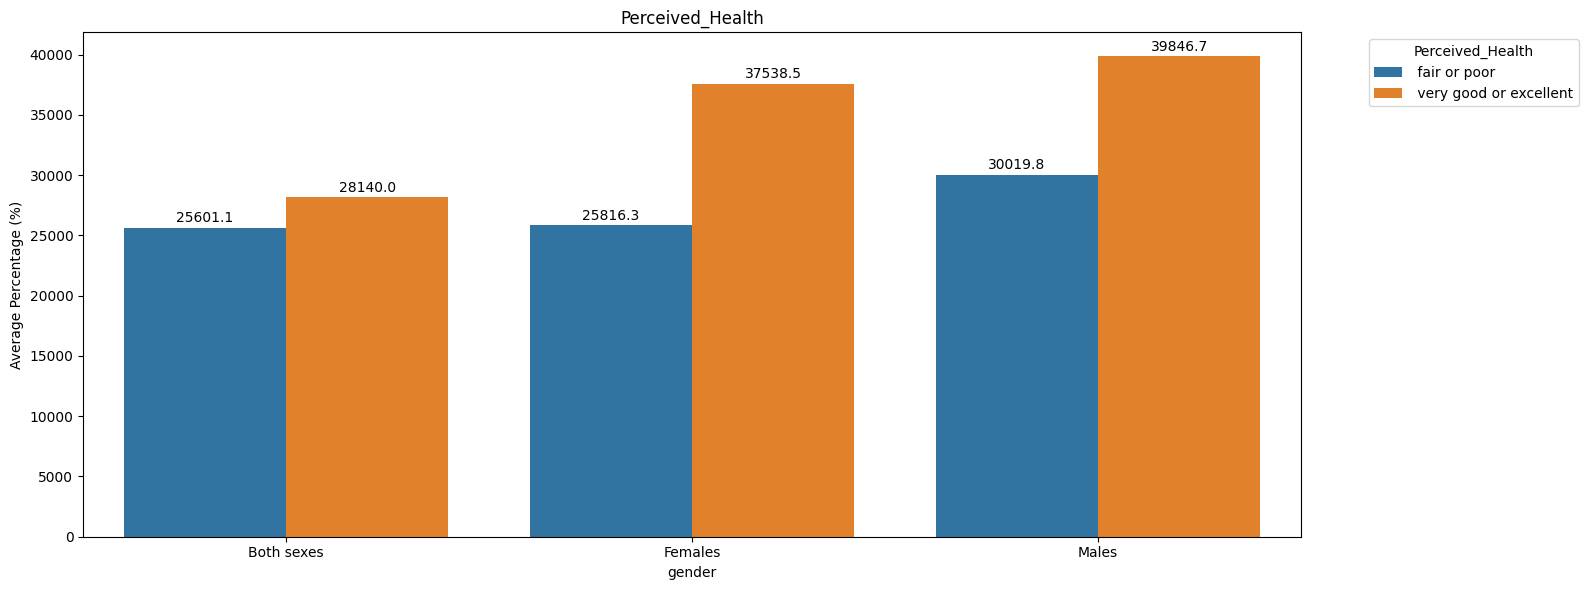

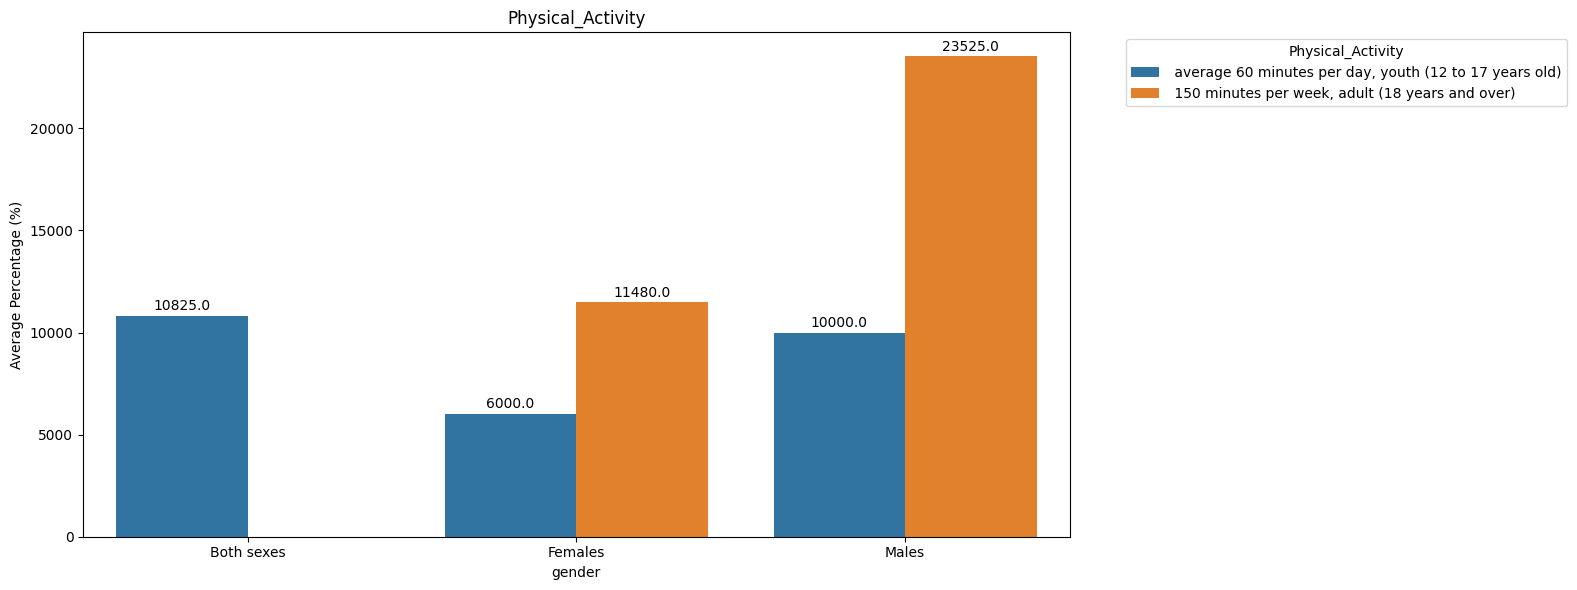

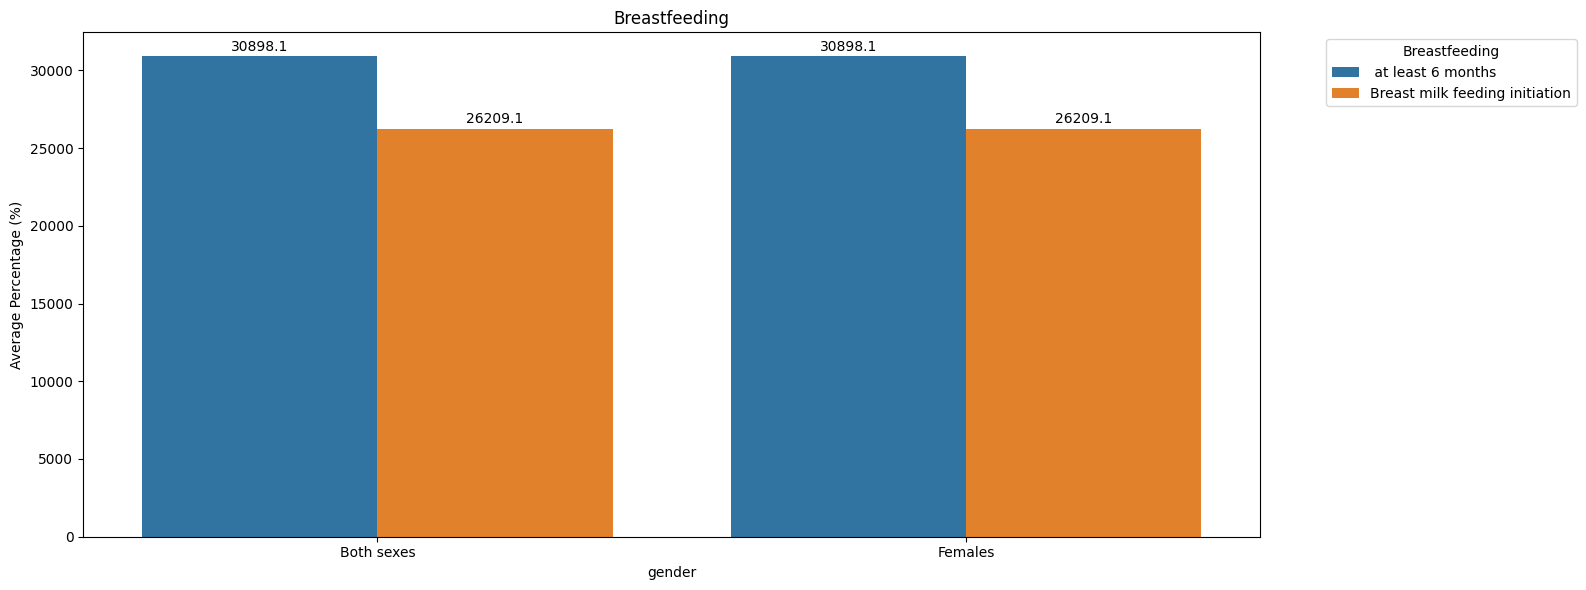

In [102]:
# Plot by Gender
for col in cols_to_plot:
    plot_bar_chart(counts, 'gender', col, col, stacked_by=False)

# Plot by Geographic Location

> Percentages

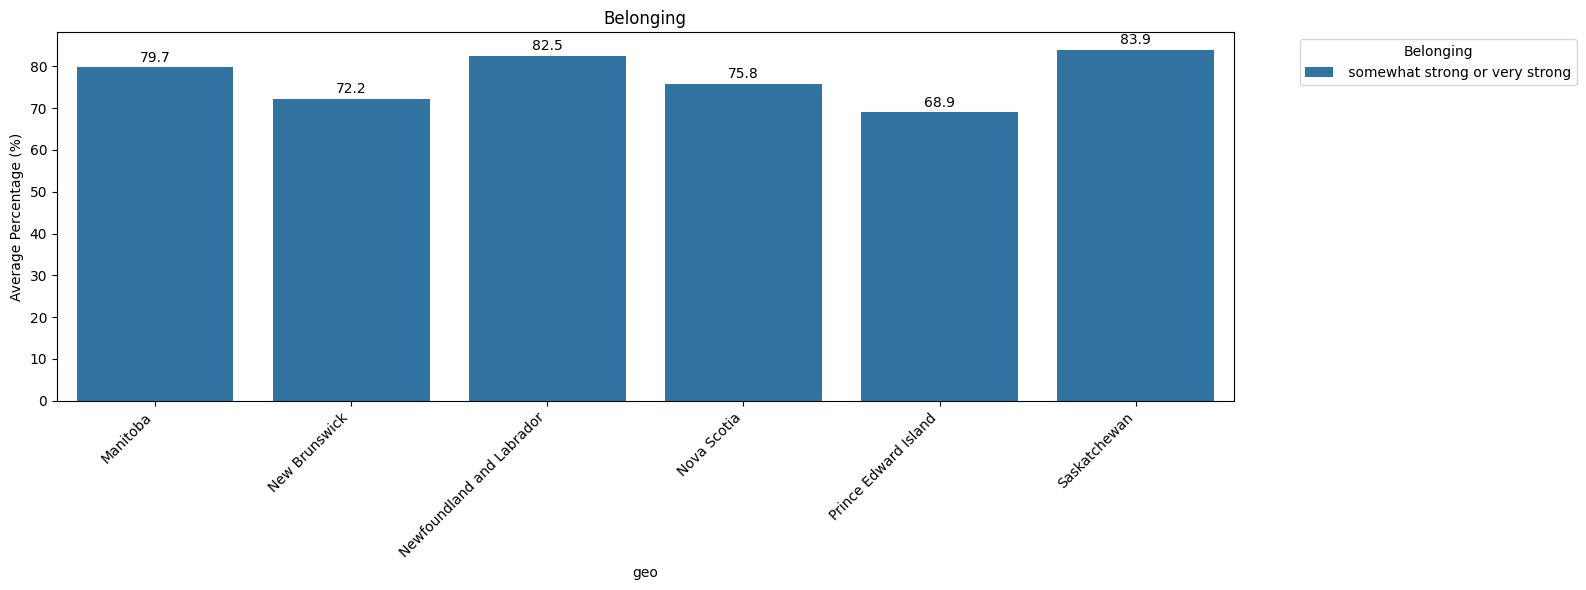

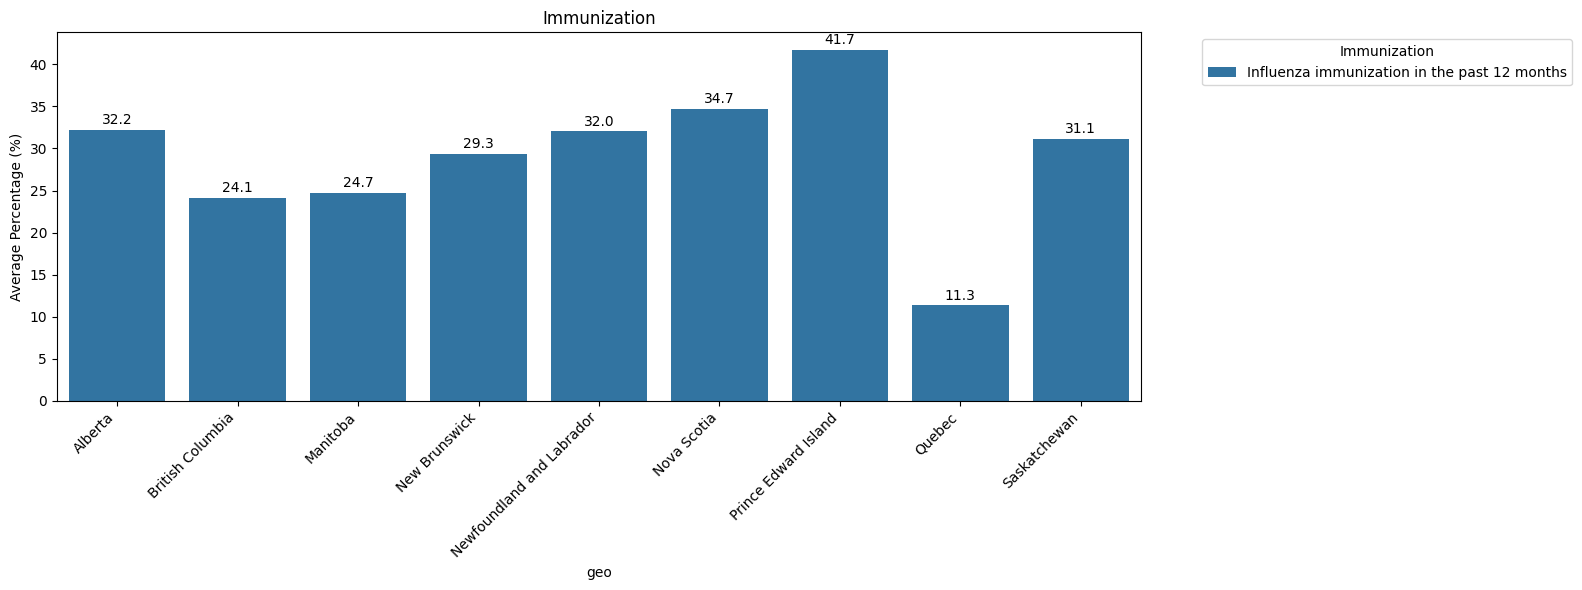

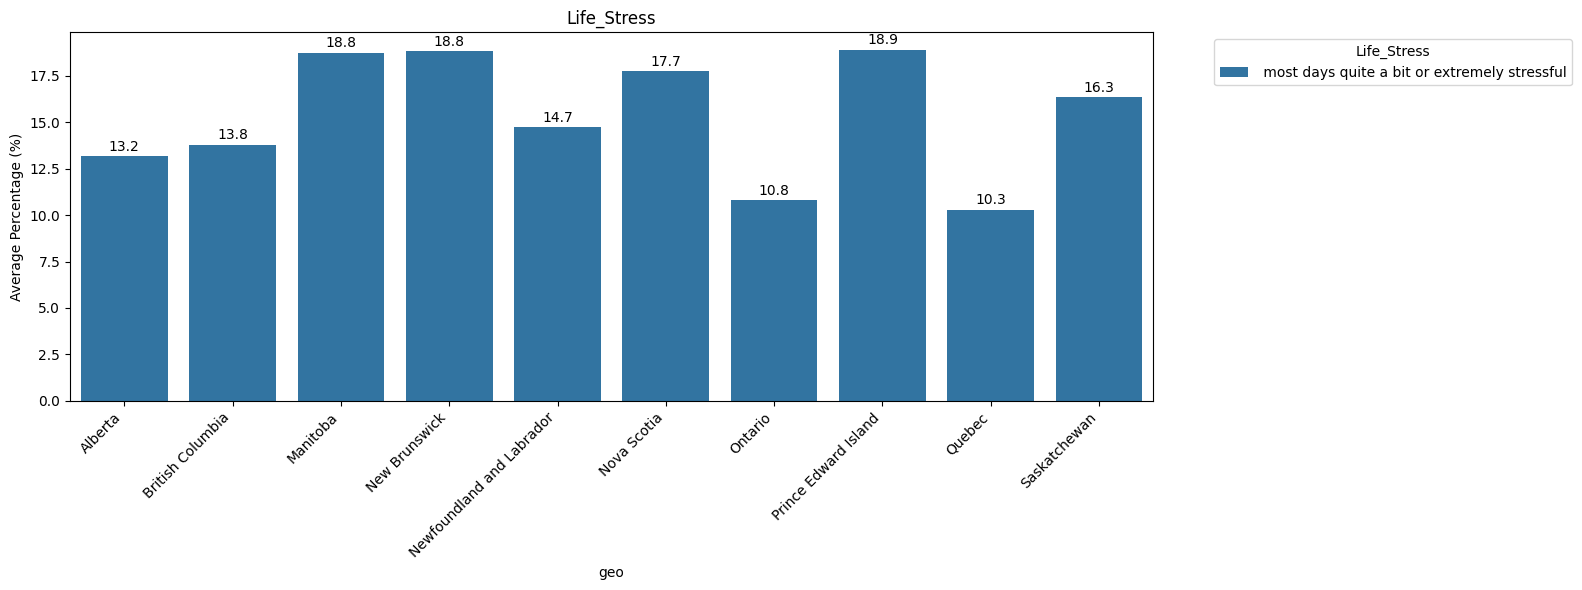

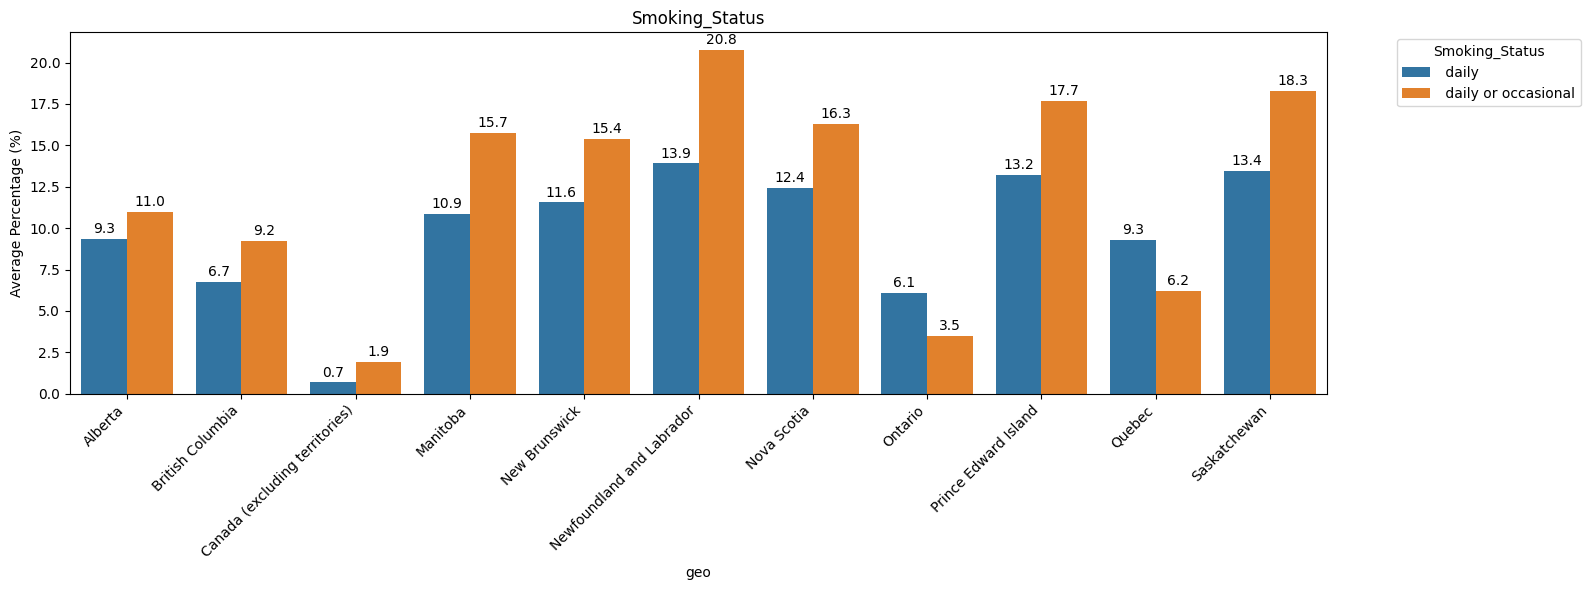

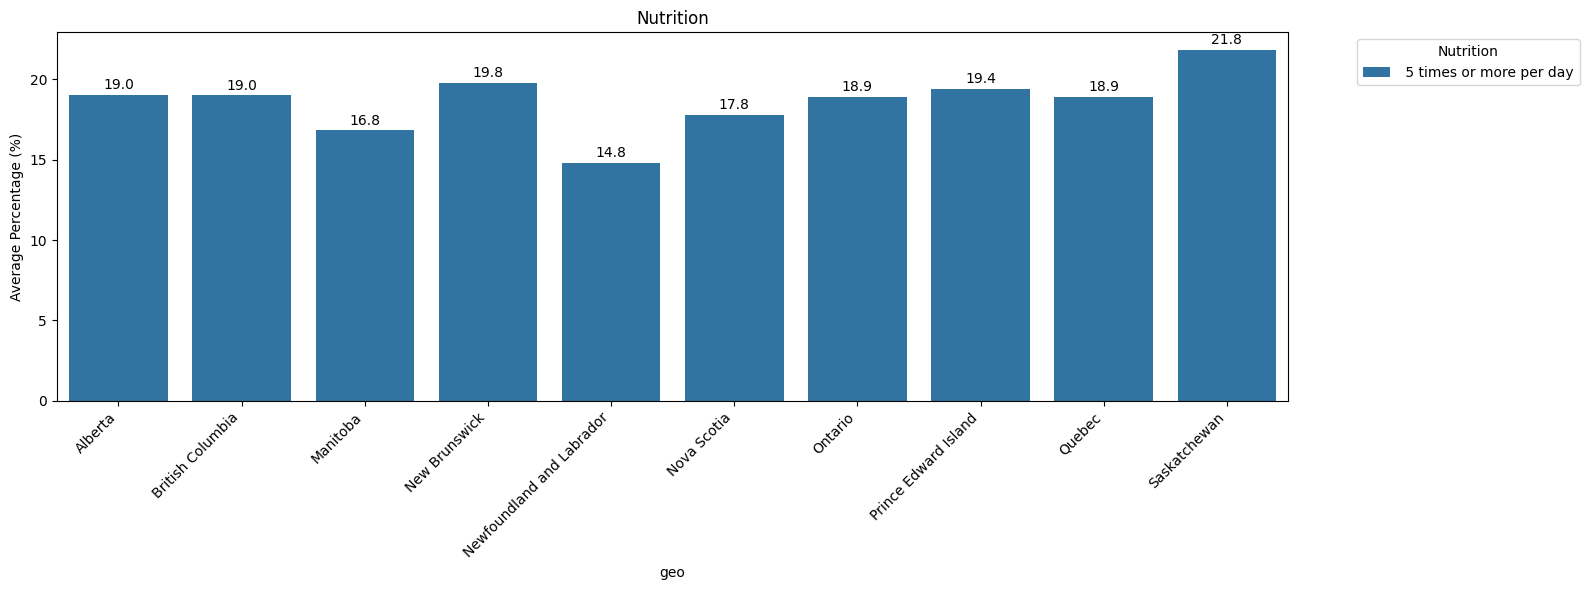

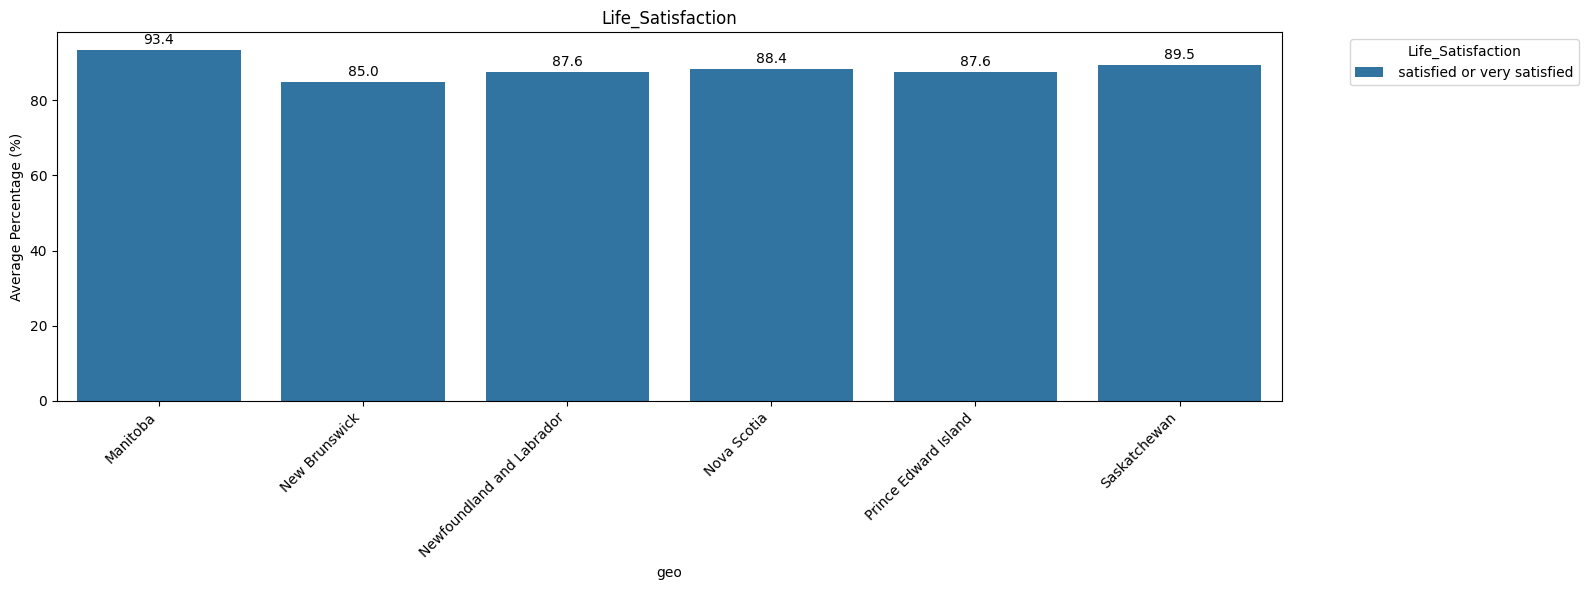

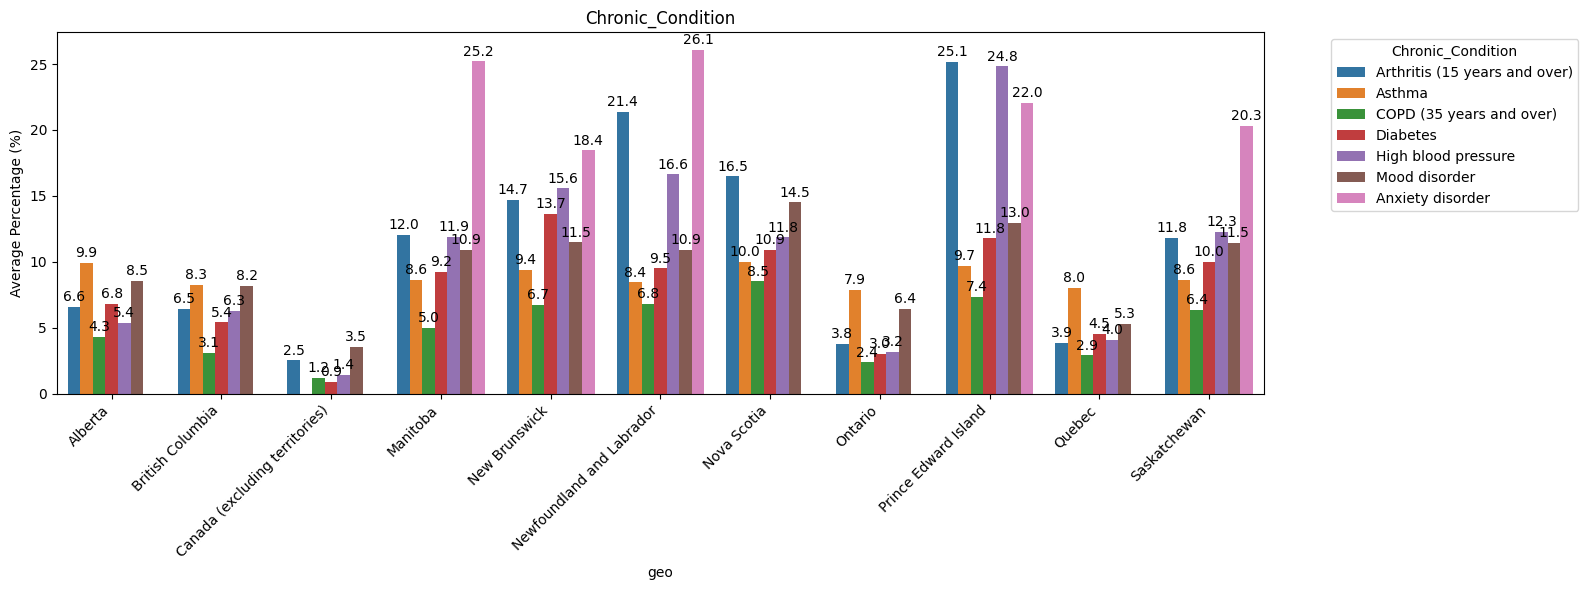

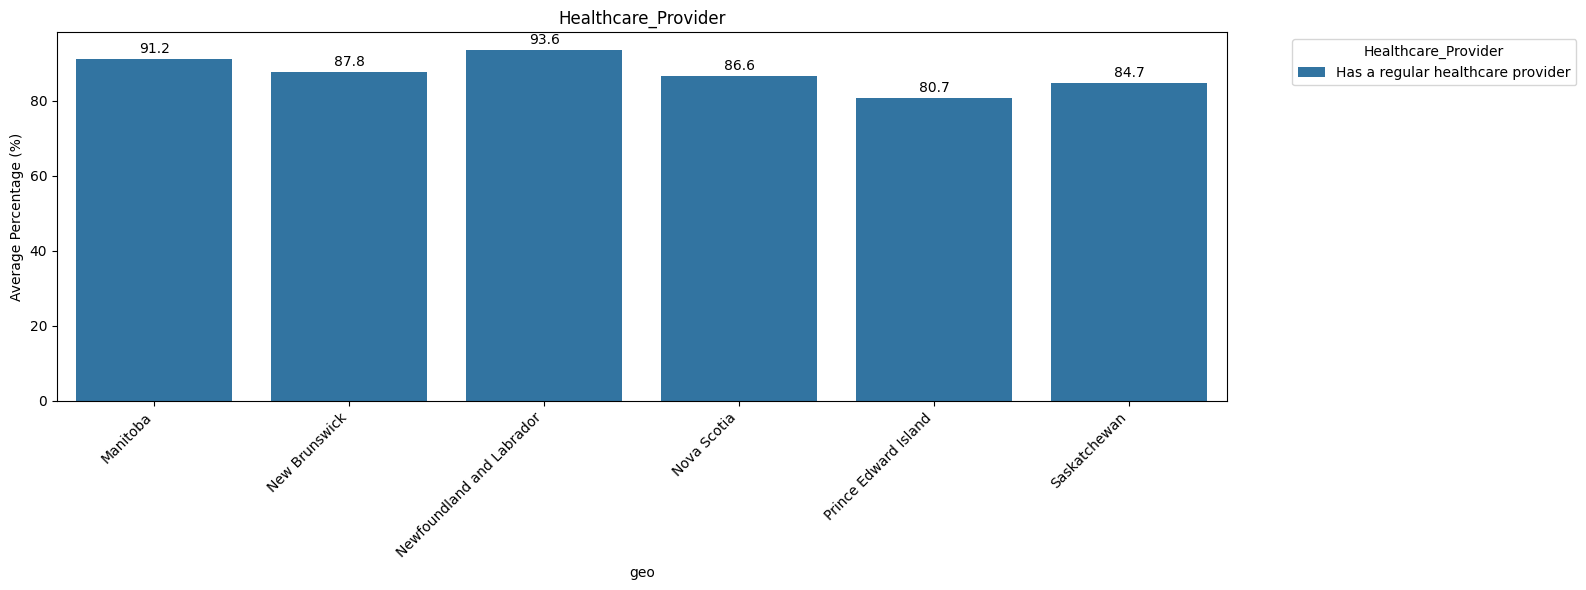

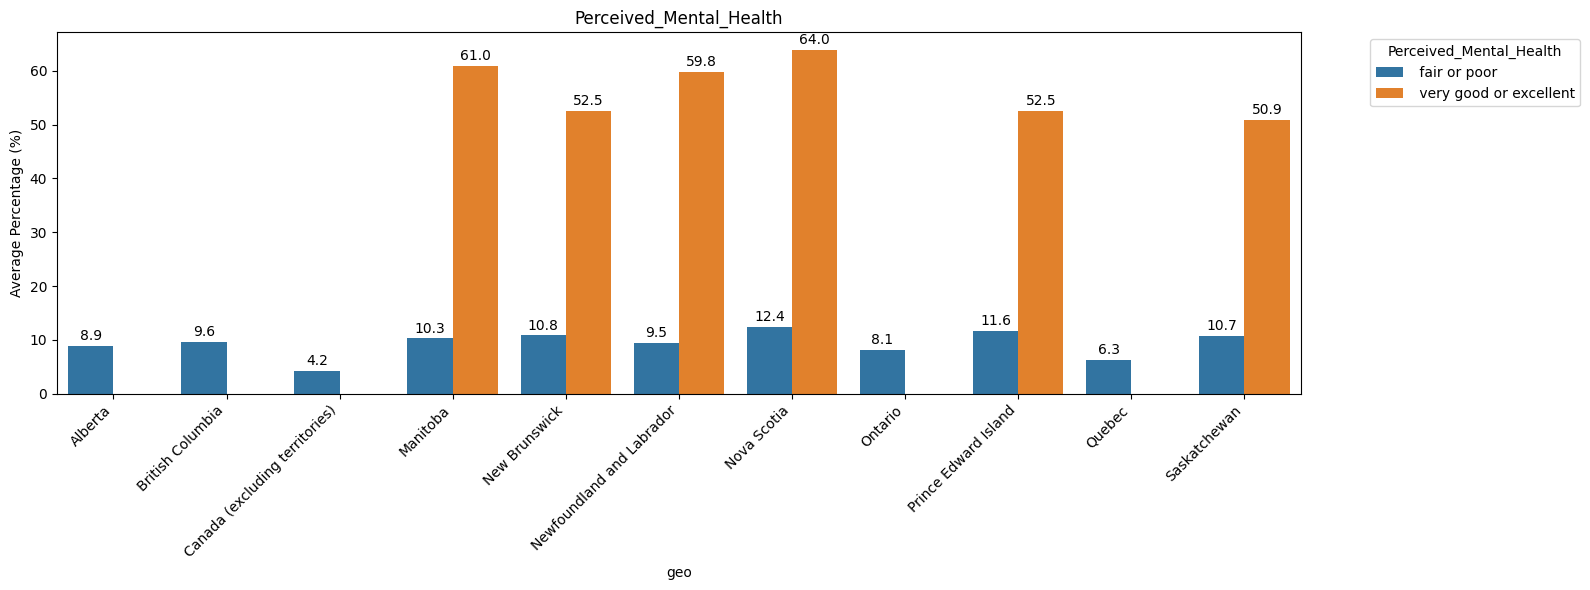

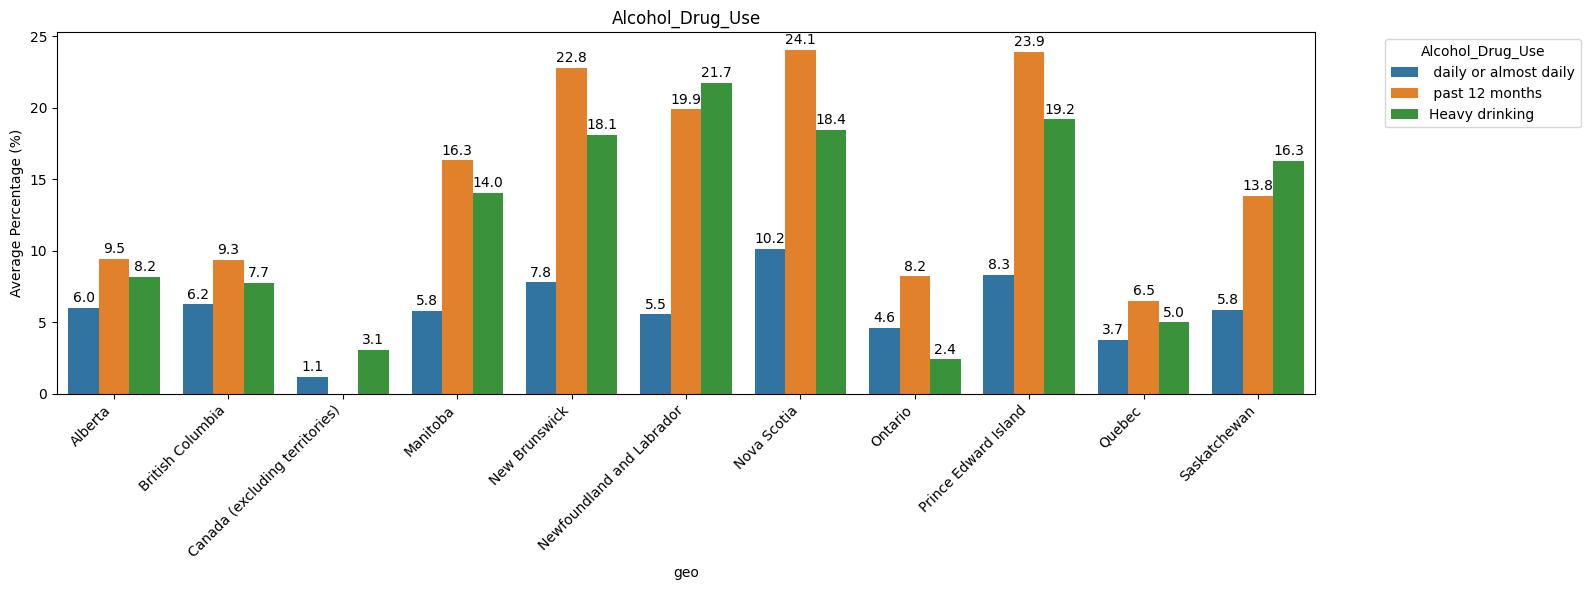

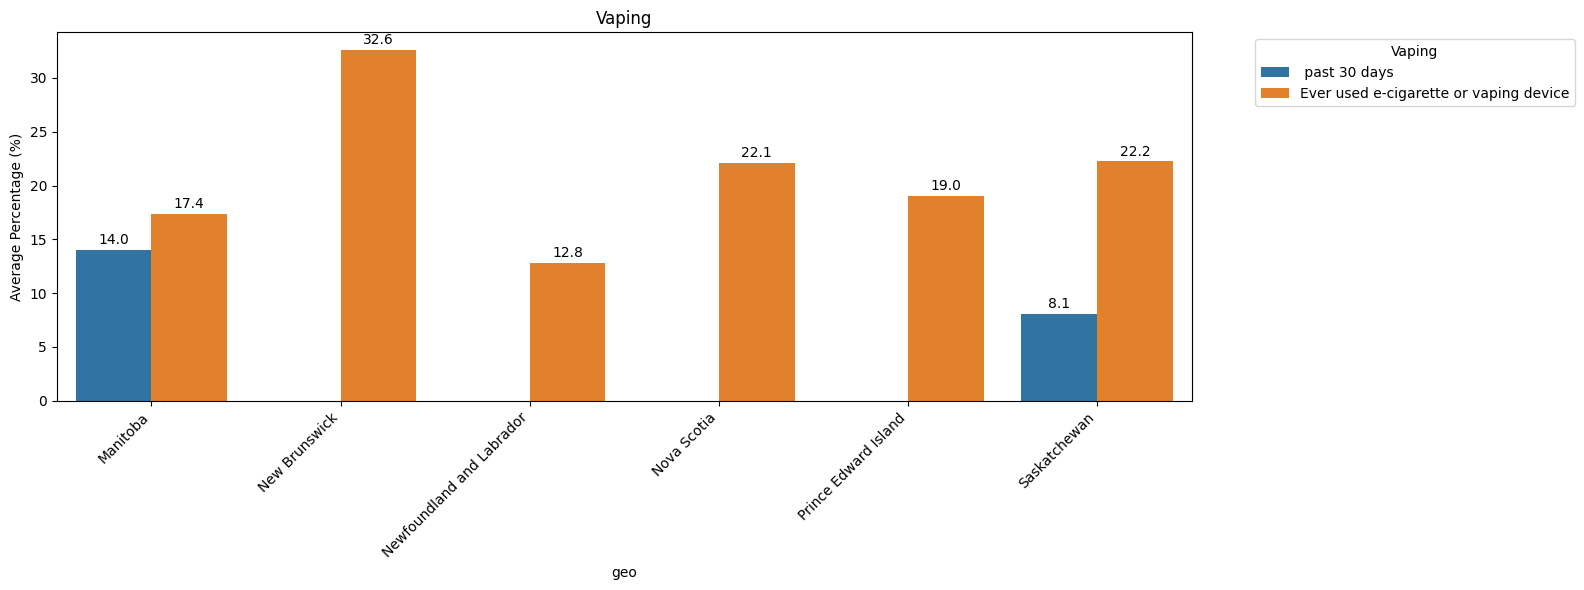

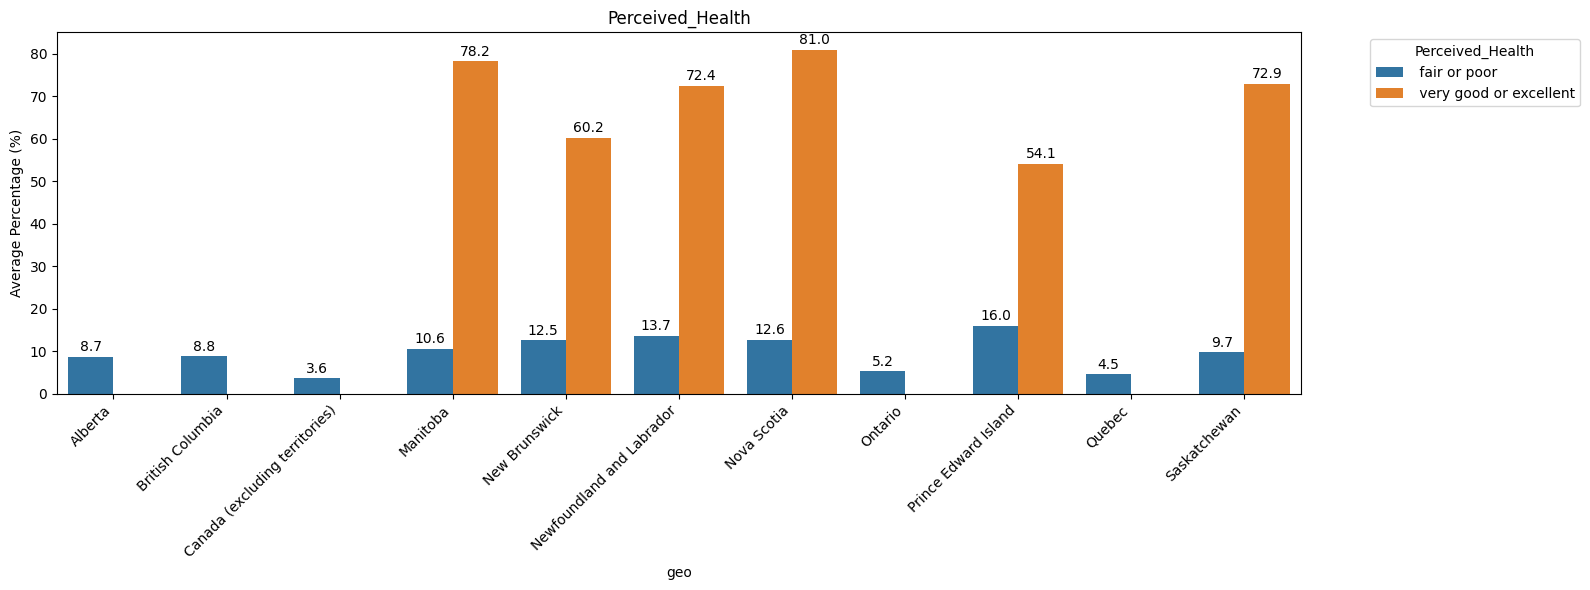

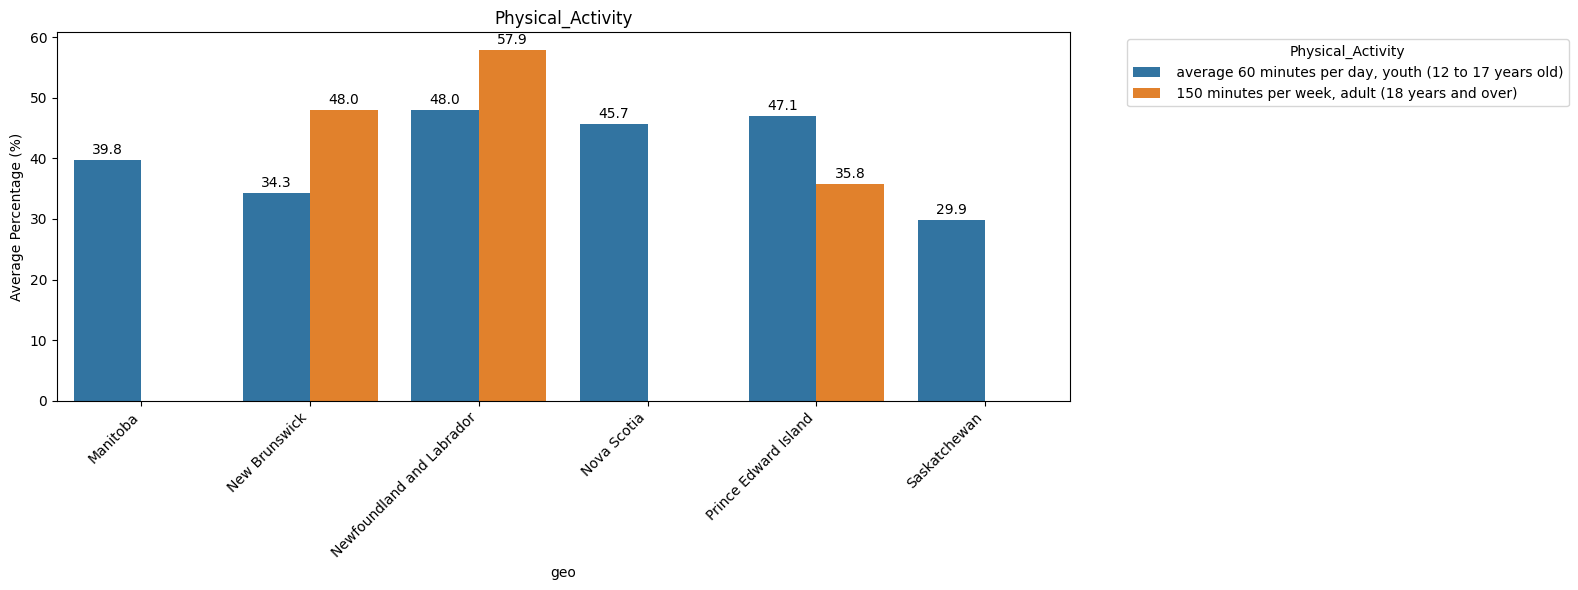

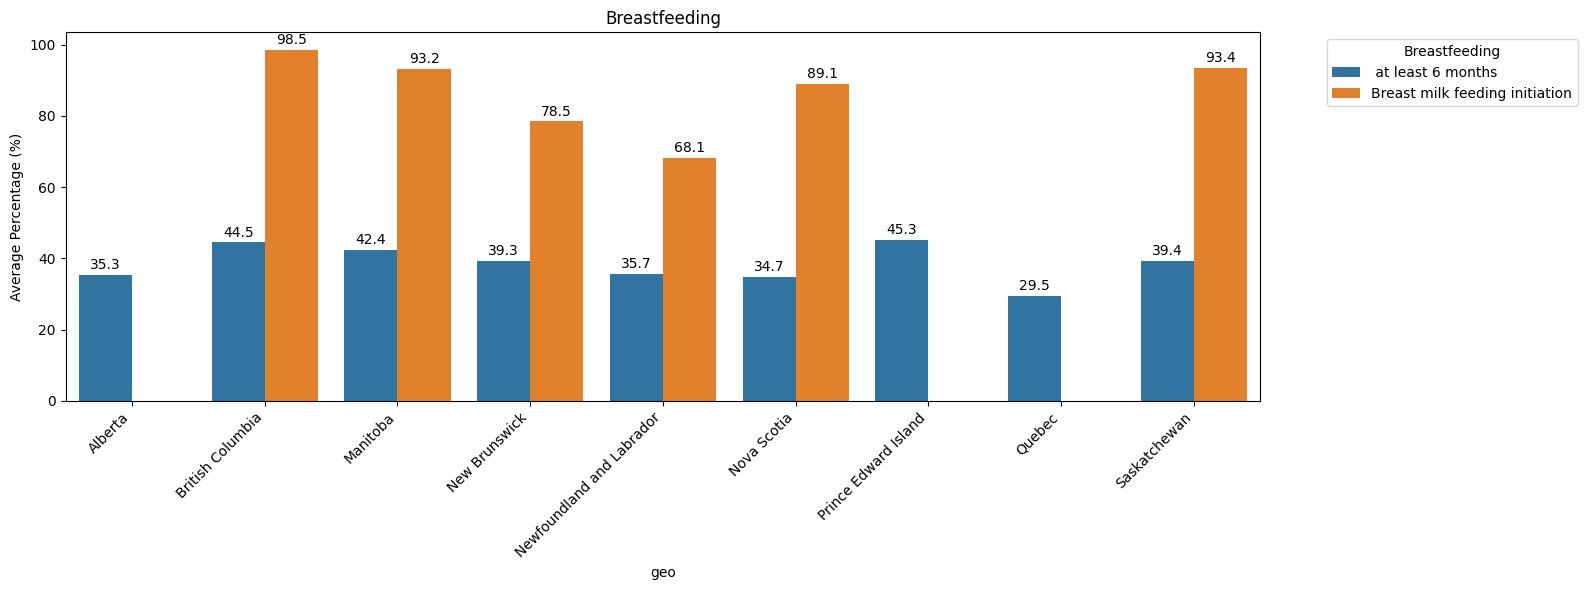

In [103]:
# Plot by Geographic Location
for col in cols_to_plot:
    plot_bar_chart(percentages, 'geo', col, col, stacked_by=False, rotate=45)

> Counts

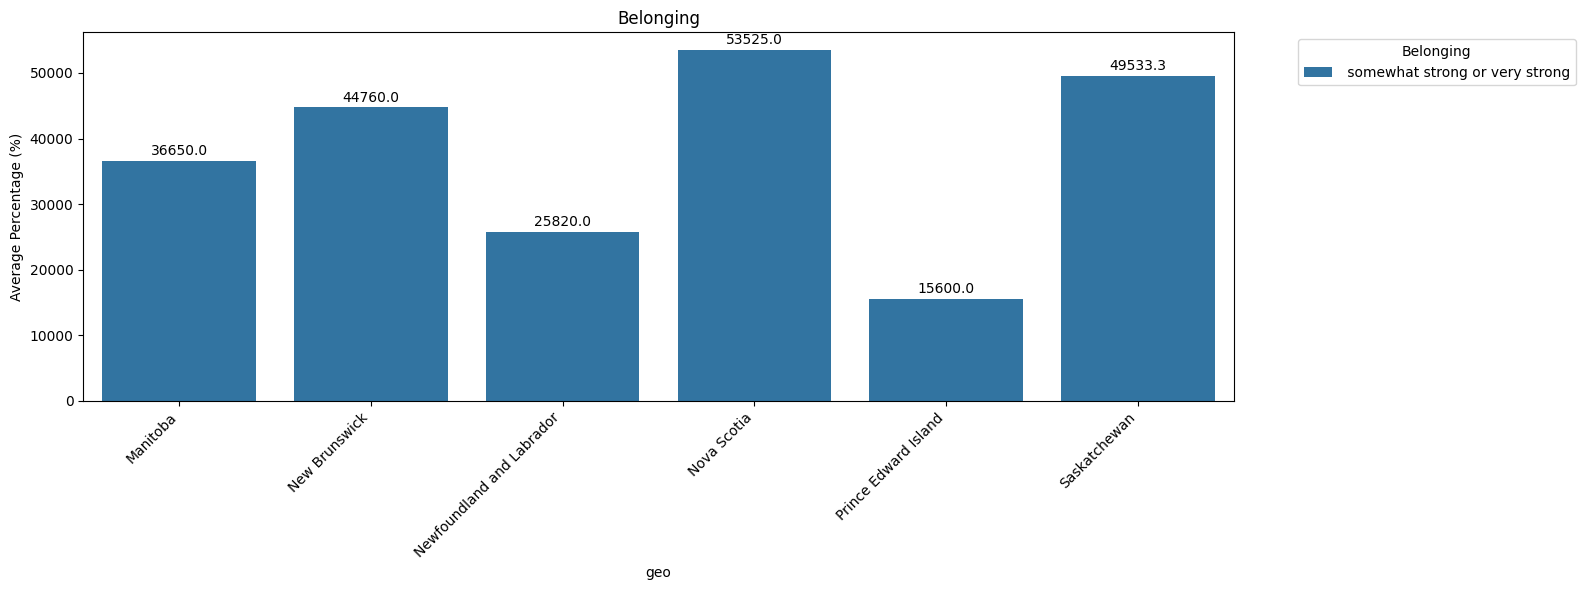

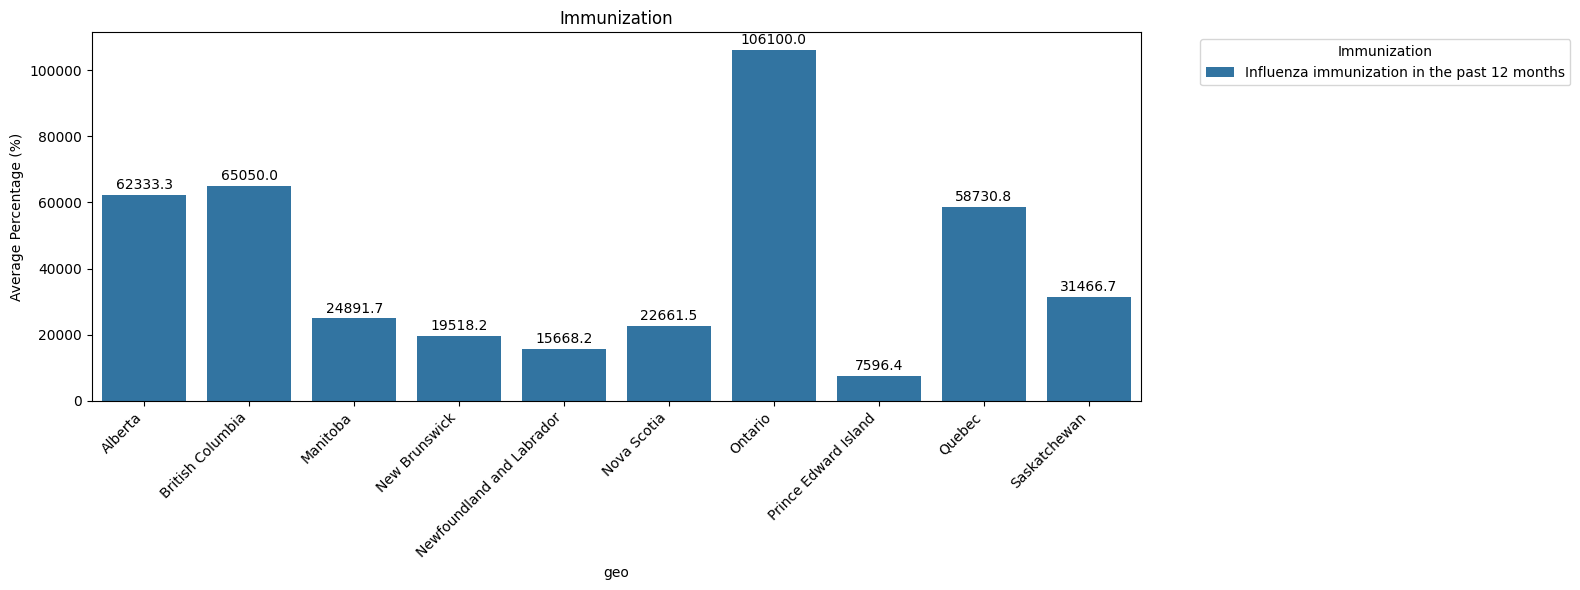

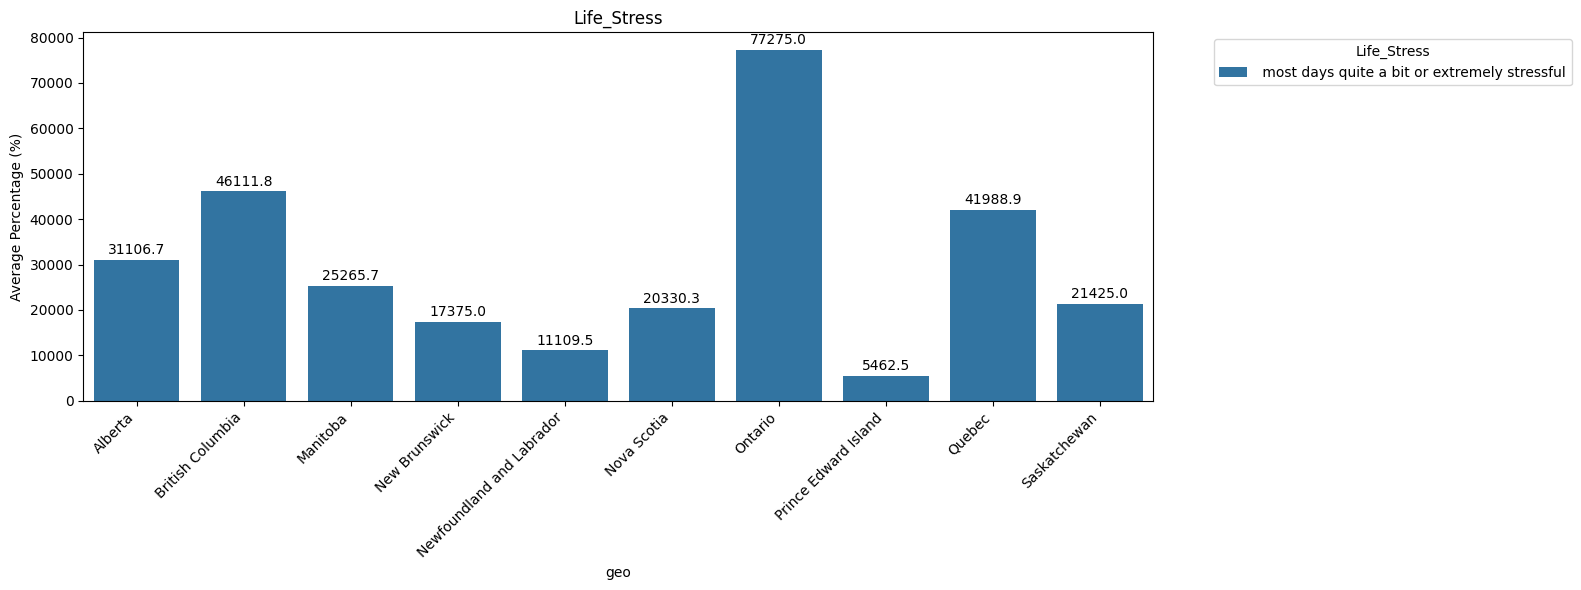

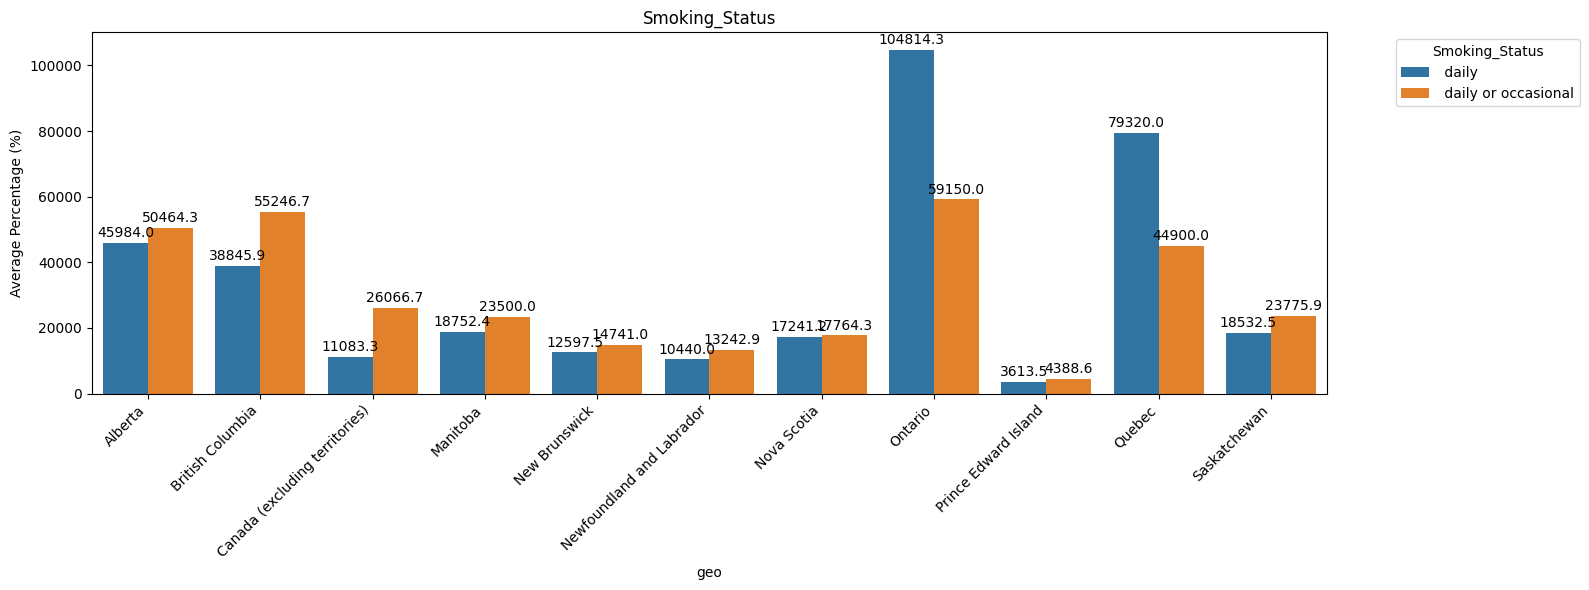

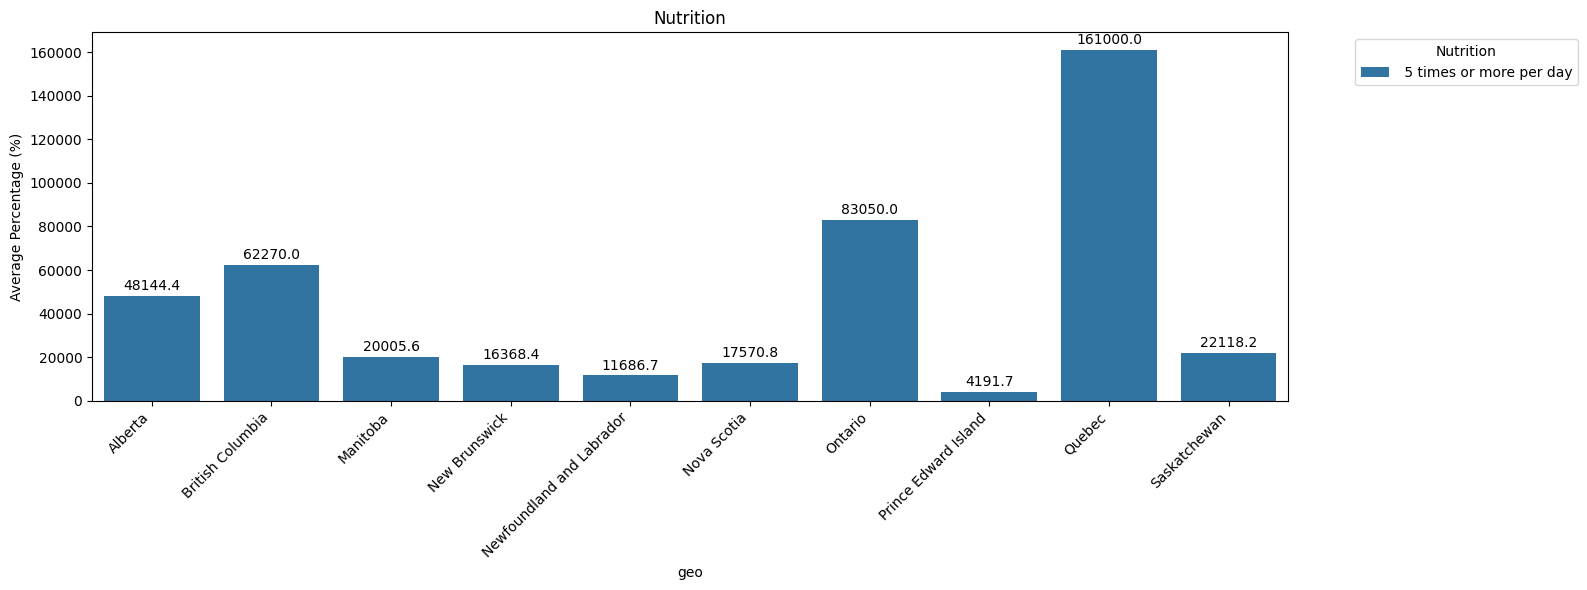

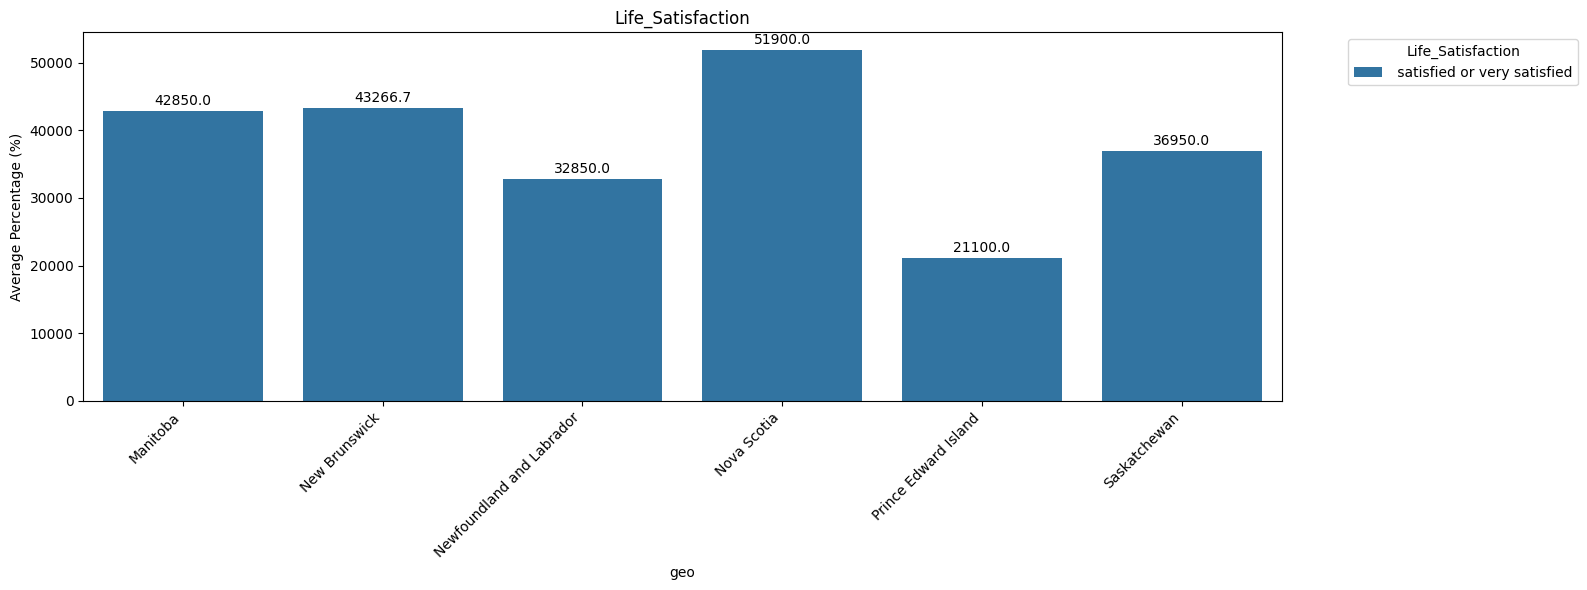

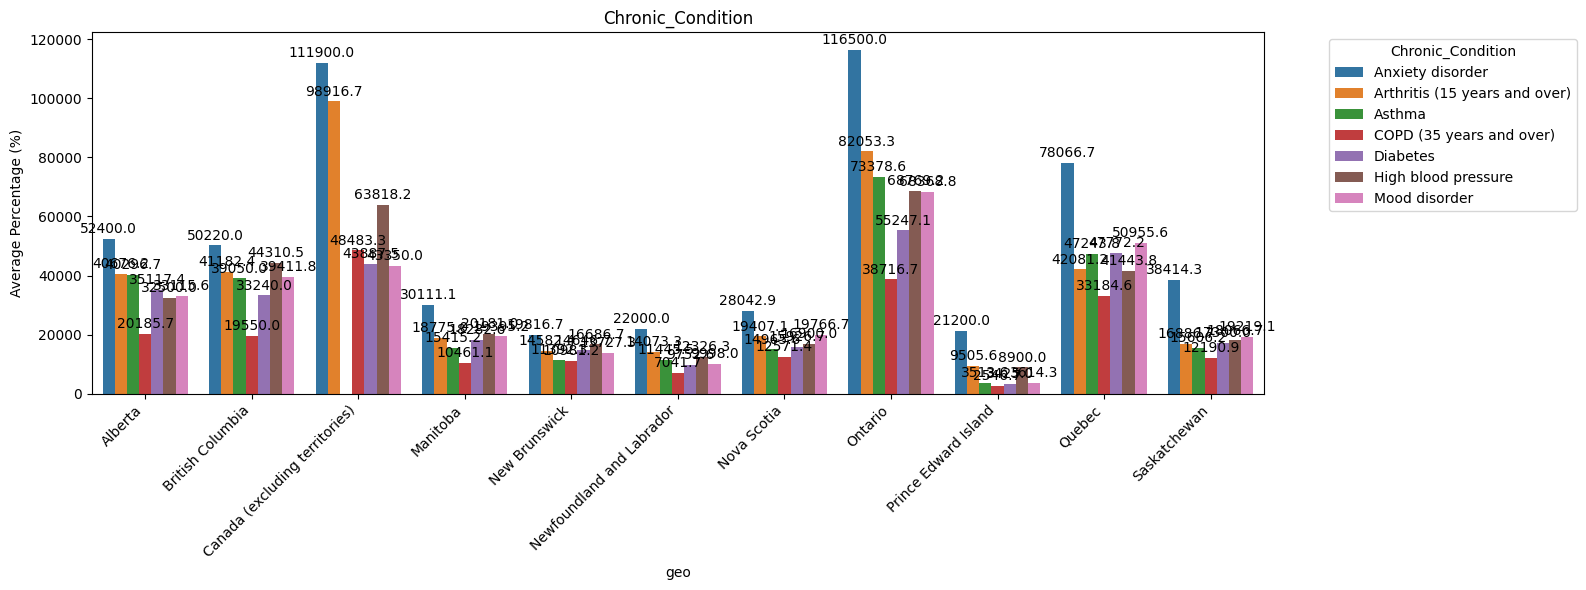

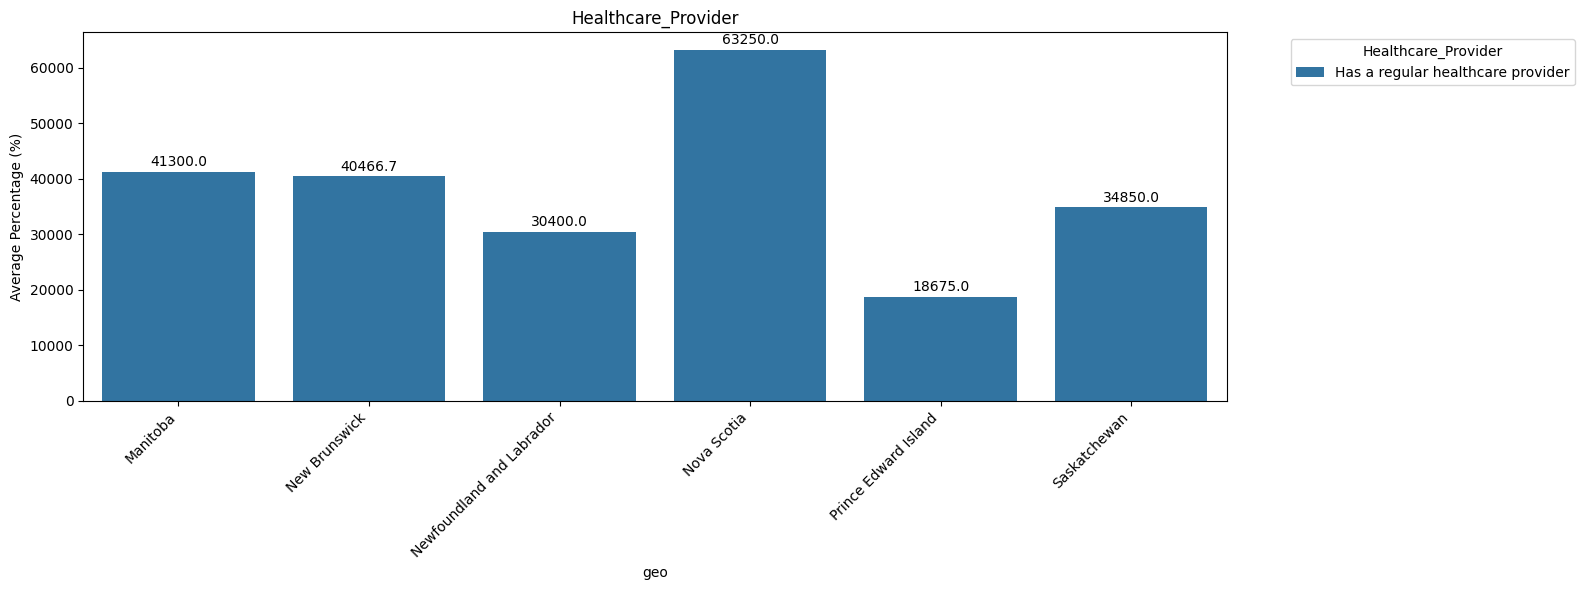

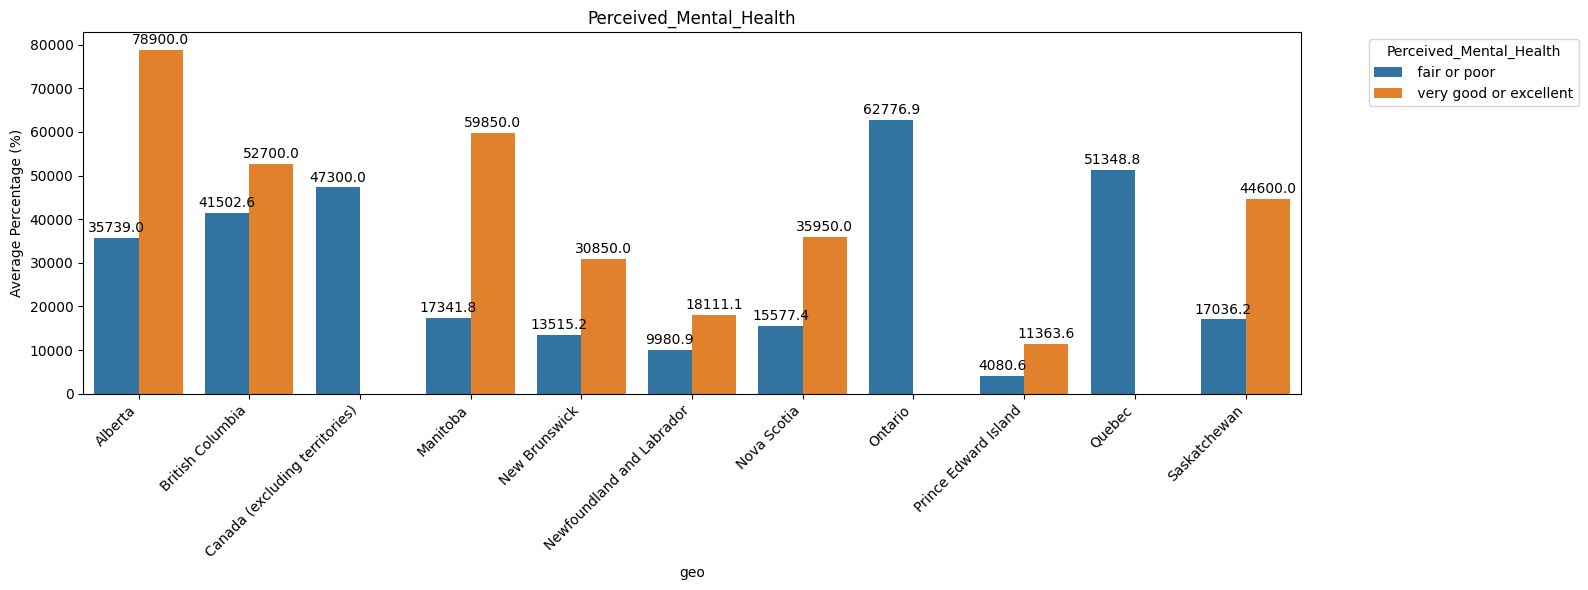

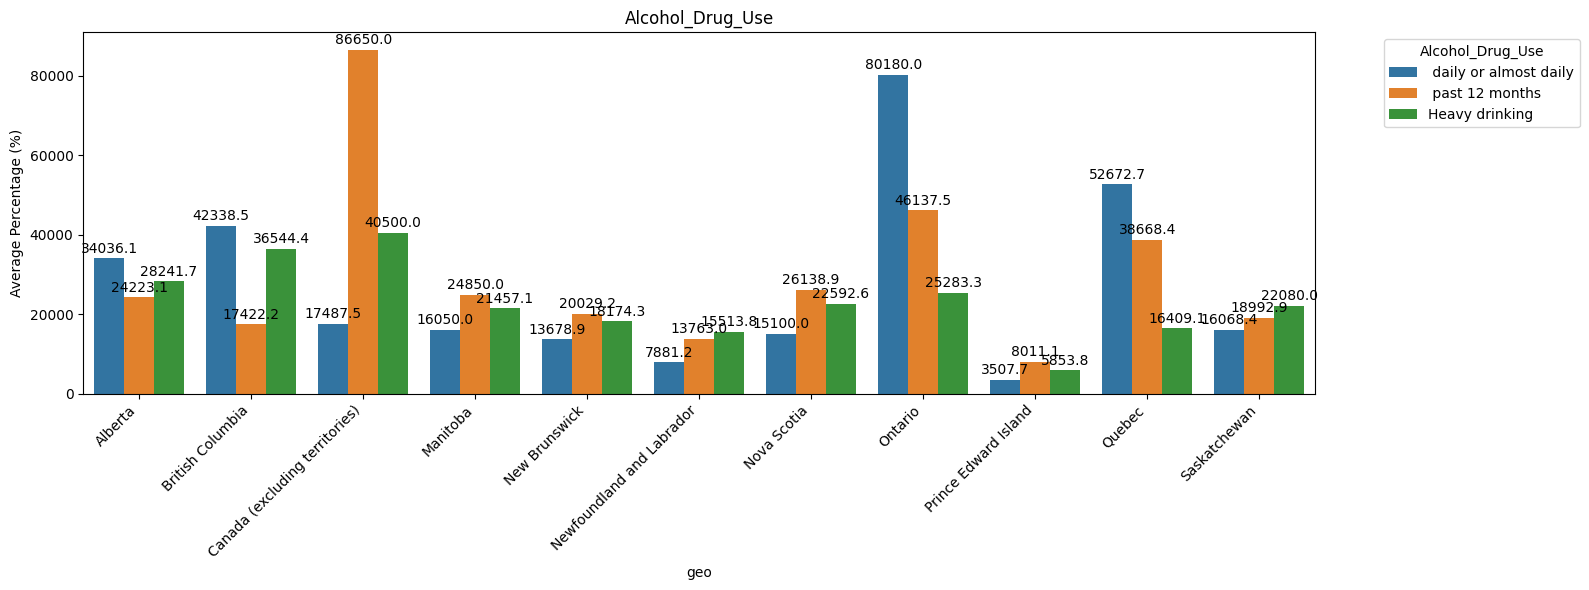

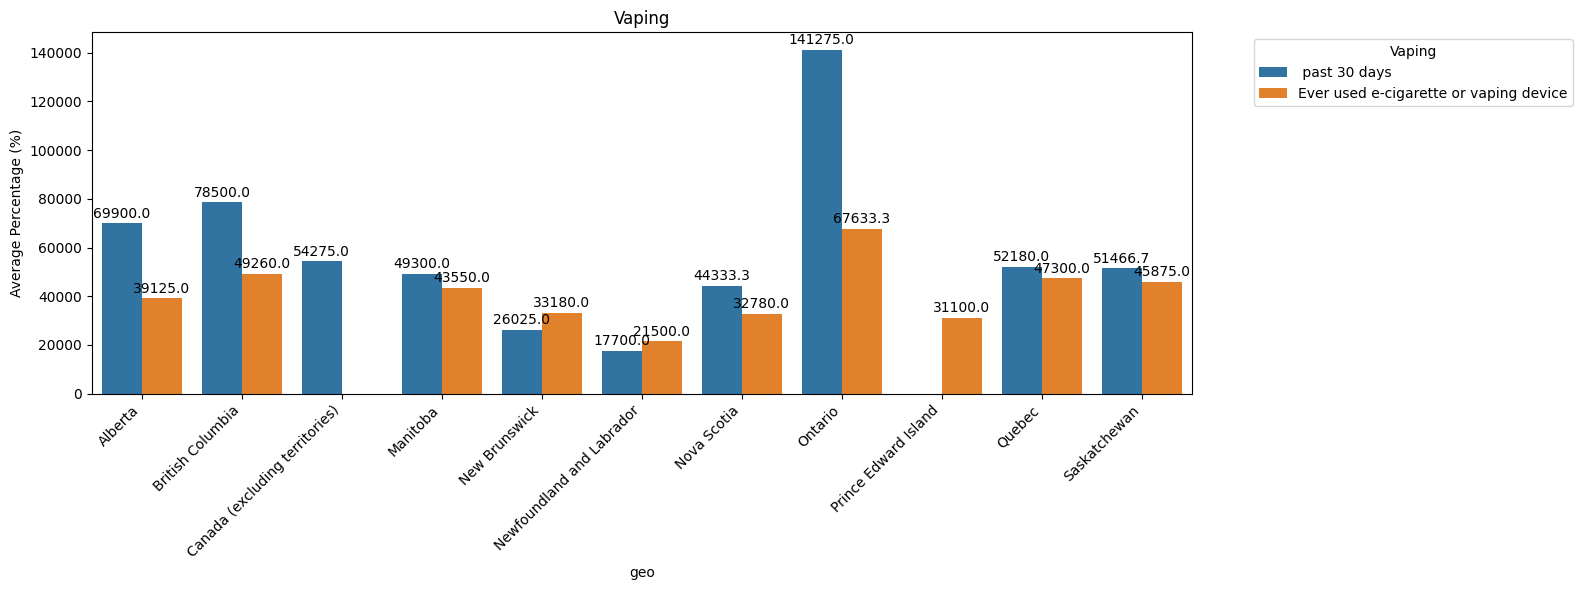

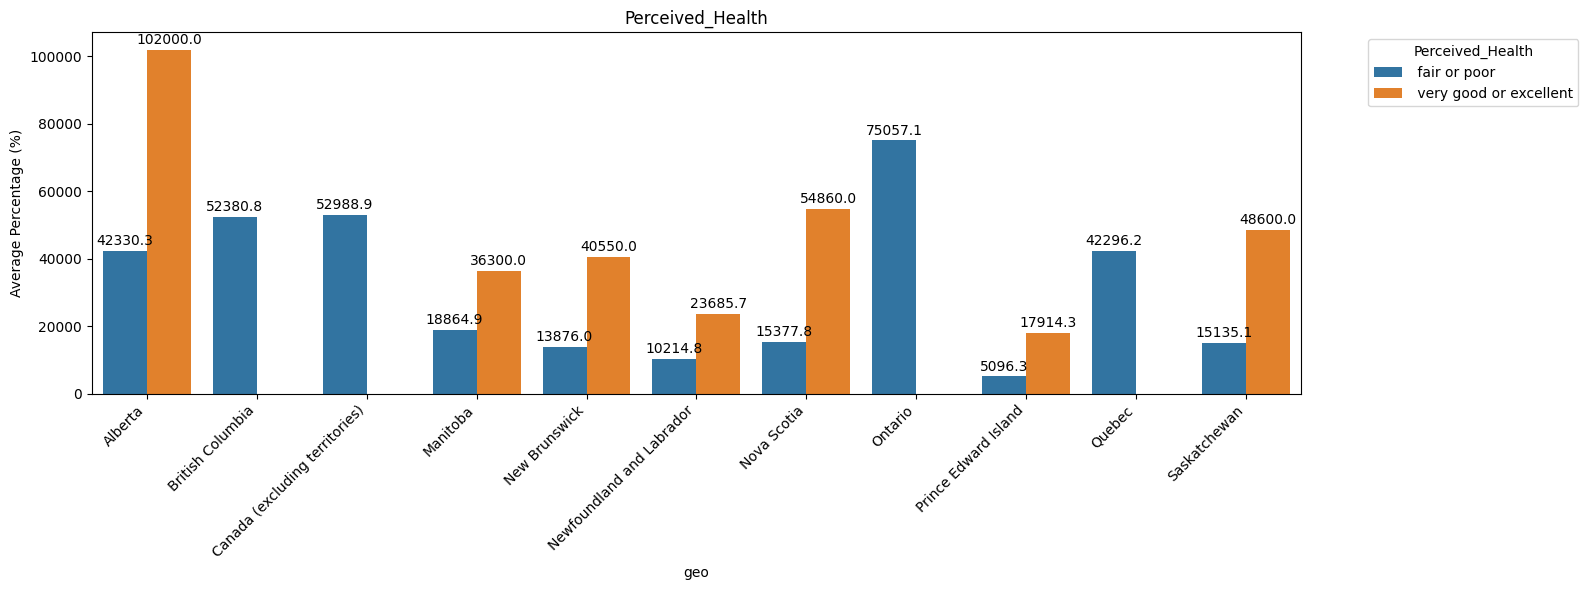

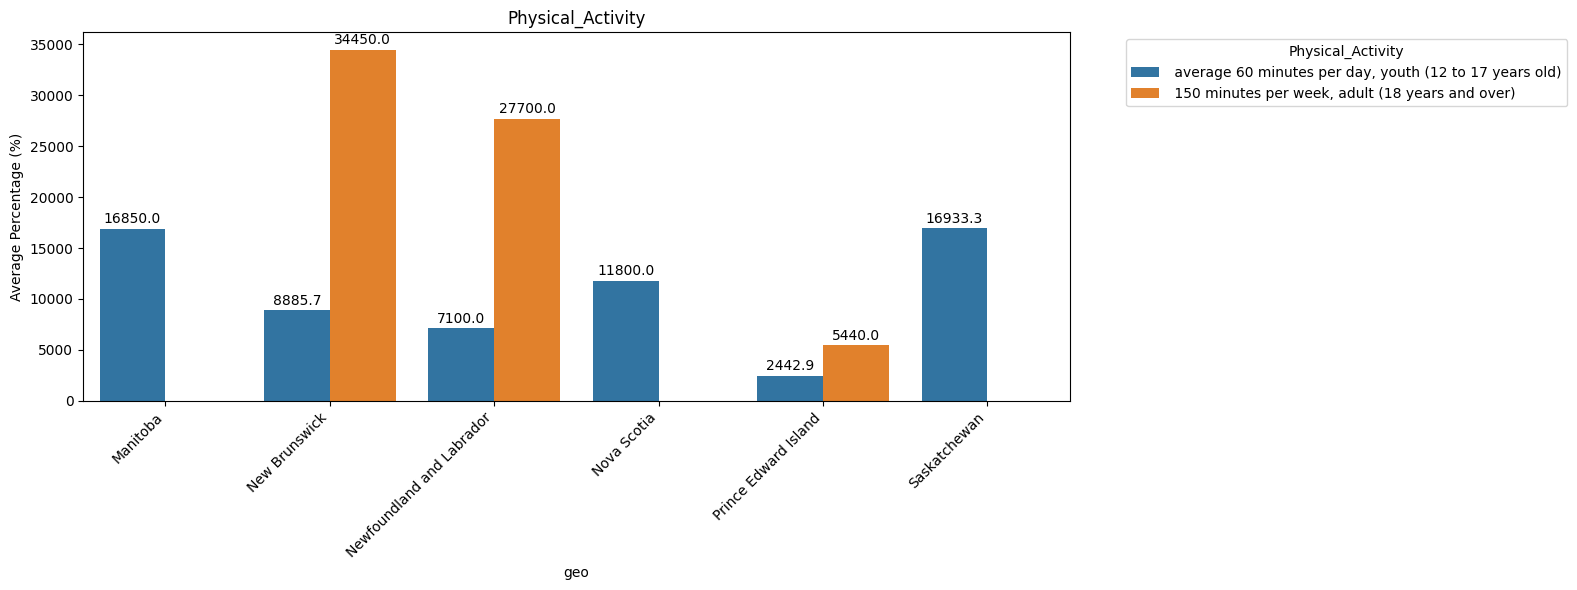

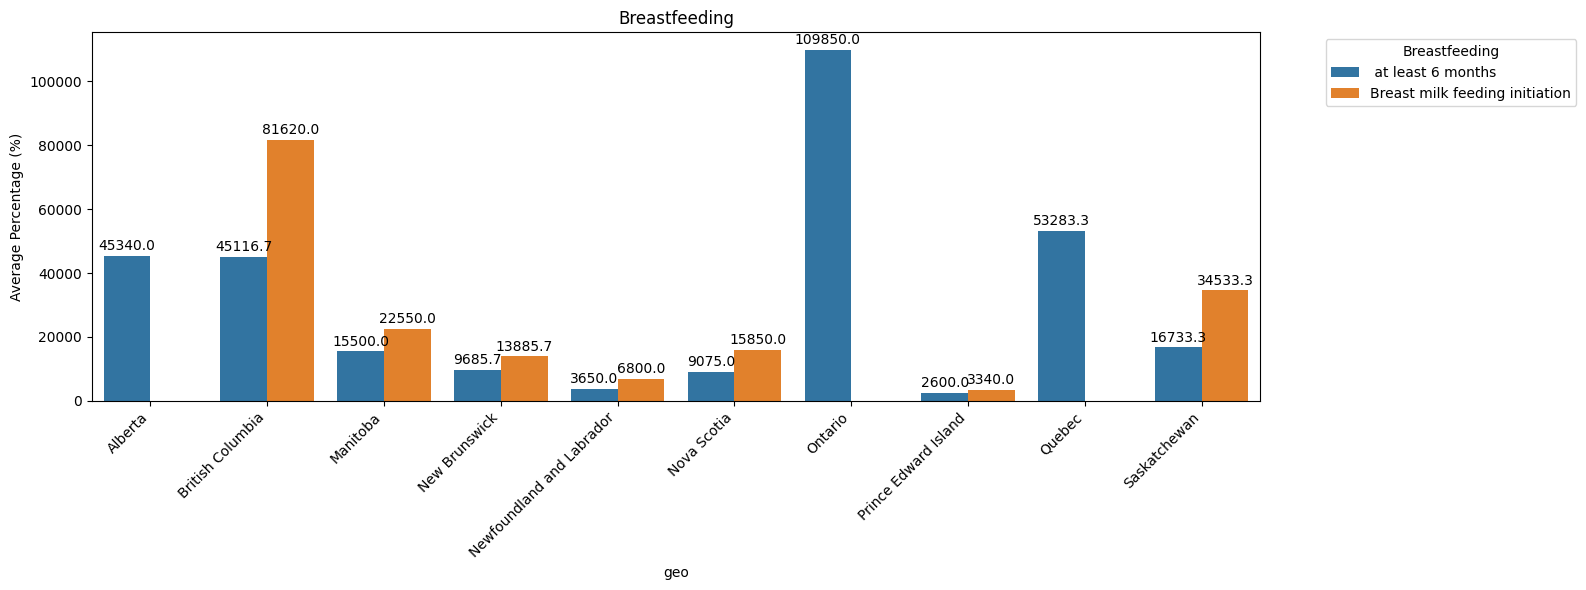

In [104]:
# Plot by Geographic Location
for col in cols_to_plot:
    plot_bar_chart(counts, 'geo', col, col, stacked_by=False, rotate=45)